### Loading all the required libraries

In [2]:
import pandas as pd
import numpy as np
import math
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc, cohen_kappa_score, matthews_corrcoef, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.utils.multiclass import unique_labels
from sklearn.metrics.pairwise import pairwise_distances
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
import graphviz
from fuzzywuzzy import process
from itertools import combinations
from aeon.distances import distance as aeon_distance
from aeon.distances import pairwise_distance as aeon_pairwise_distance
from aeon.datasets import load_from_tsfile_to_dataframe
from collections import Counter
from aeon.datasets import load_from_tsfile
from IPython.display import display
import os
from scipy.io import arff
from pycatch22 import catch22_all  #!pip install pycatch22
from scipy.spatial.distance import euclidean

### The Univariate dataset is sorted based on train and test and number of classes

In [3]:
# Load the dataset
file_path = 'UCRArchive_2018/DataSummary.csv'
data_summary = pd.read_csv(file_path)

# Clean up the column names (strip any extra spaces)
data_summary.columns = data_summary.columns.str.strip()

# Convert relevant columns to numeric, forcing errors to NaN
data_summary['Length'] = pd.to_numeric(data_summary['Length'], errors='coerce')
data_summary['Train'] = pd.to_numeric(data_summary['Train'], errors='coerce')
data_summary['Class'] = pd.to_numeric(data_summary['Class'], errors='coerce')
data_summary['Test'] = pd.to_numeric(data_summary['Test'], errors='coerce')

# Drop rows with missing values in any of the relevant columns
data_summary = data_summary.dropna(subset=['Train', 'Length', 'Class', 'Test'])

# Create new columns for the custom sorting criteria
data_summary['Train_Length'] = data_summary['Train'] * data_summary['Length']
data_summary['Test_Length'] = data_summary['Test'] * data_summary['Length']

# Sort the dataset by 'Train_Length', 'Test_Length', and 'Class' in ascending order
sorted_data_summary = data_summary.sort_values(by=['Train_Length', 'Test_Length', 'Class'], ascending=[True, True, True])

# Drop the temporary columns used for sorting
sorted_data_summary = sorted_data_summary.drop(columns=['Train_Length', 'Test_Length'])

# Display the sorted DataFrame
print(sorted_data_summary)

    ID     Type                        Name  Train  Test  Class  Length  \
90  91  Traffic                   Chinatown     20   343      2    24.0   
63  64   Sensor       SonyAIBORobotSurface1     20   601      2    70.0   
37  38   Sensor            ItalyPowerDemand     67  1029      2    24.0   
47  48   Sensor                  MoteStrain     20  1252      2    84.0   
64  65   Sensor       SonyAIBORobotSurface2     27   953      2    65.0   
..  ..      ...                         ...    ...   ...    ...     ...   
48  49      ECG  NonInvasiveFetalECGThorax1   1800  1965     42   750.0   
49  50      ECG  NonInvasiveFetalECGThorax2   1800  1965     42   750.0   
28  29   Sensor                       FordA   3601  1320      2   500.0   
29  30   Sensor                       FordB   3636   810      2   500.0   
32  33    Image                HandOutlines   1000   370      2  2709.0   

    ED (w=0) DTW (learned_w)  DTW (w=100)  Default rate  \
90    0.0466      0.0466 (0)       0.043

### Scatter plot of the whole dataset

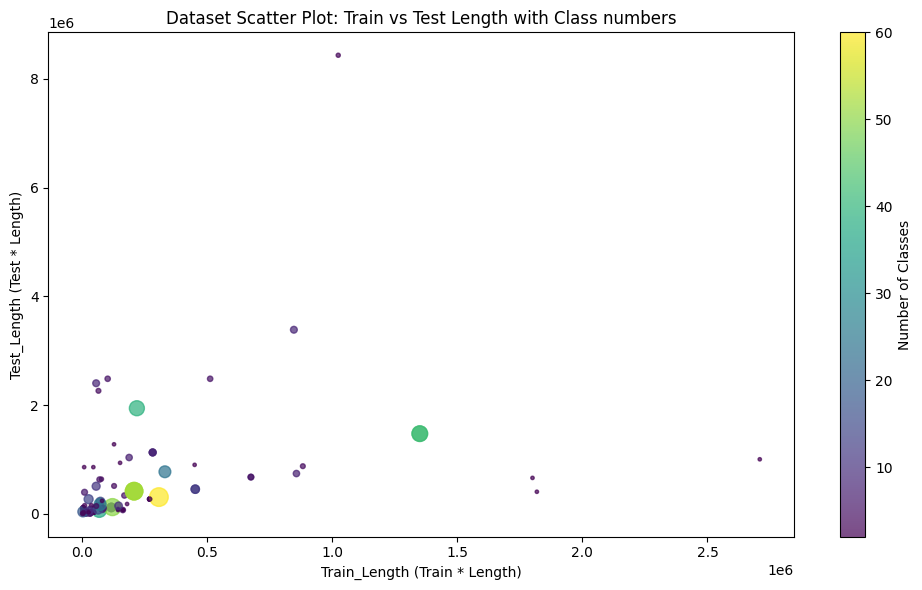

In [4]:
plt.figure(figsize=(10, 6))

# Plot the scatter plot with 'Train_Length' on the x-axis, 'Test_Length' on the y-axis, and point size based on 'Class'
scatter = plt.scatter(
    data_summary['Train_Length'],
    data_summary['Test_Length'],
    s=data_summary['Class'] * 3,   # Scale the size of points by the number of classes
    c=data_summary['Class'],       # Use 'Class' to color the points
    cmap='viridis',                # Use a colormap to differentiate classes
    alpha=0.7                      # Set transparency
)

# Add labels and title
plt.xlabel('Train_Length (Train * Length)')
plt.ylabel('Test_Length (Test * Length)')
plt.title('Dataset Scatter Plot: Train vs Test Length with Class numbers')

# Add a color bar to explain the colors based on 'Class'
colorbar = plt.colorbar(scatter)
colorbar.set_label('Number of Classes')

# Show the plot
plt.tight_layout()
plt.show()

### Load and split the Univariate dataset for the model (Insert the dataset's name)

In [5]:
# Load the dataset names from the file
file_path = 'UCRArchive_2018/DataSummary.csv'
dataset_df = pd.read_csv(file_path)

# Extract dataset names from the "Name" column
dataset_names = dataset_df['Name'].tolist()

# Function to load the dataset based on the provided dataset name
def load_dataset(dataset_name):
    try:
        train_path = f'UCRArchive_2018/{dataset_name}/{dataset_name}_TRAIN.tsv'
        test_path = f'UCRArchive_2018/{dataset_name}/{dataset_name}_TEST.tsv'
        
        # Load training and test data
        train_data = pd.read_csv(train_path, header=None, sep='\t')
        test_data = pd.read_csv(test_path, header=None, sep='\t')
        
        print(f"{dataset_name} training data shape: {train_data.shape}")
        print(f"{dataset_name} test data shape: {test_data.shape}")
        
        return train_data, test_data
    except FileNotFoundError:
        raise ValueError(f"Error: Dataset '{dataset_name}' could not be loaded. Please check the dataset name.")

# Function to check dataset validity and suggest nearest valid dataset name if not found
def check_dataset_name(dataset_name, valid_names):
    if dataset_name in valid_names:
        return dataset_name
    else:
        # Find the closest matching dataset name using fuzzy matching
        closest_match, match_score = process.extractOne(dataset_name, valid_names)
        if match_score > 60:  # Suggest if the similarity score is reasonable
            print(f"Error: Dataset '{dataset_name}' not found. Did you mean '{closest_match}'?")
        else:
            print(f"Error: Dataset '{dataset_name}' not found and no close match available.")
        return None

# Function to calculate the number of trees for a Random Forest based on dataset size
def calculate_number_of_trees(num_training_samples):

    # Constants to adjust based on experimentation
    min_trees = 200
    max_trees = 1000
    factor = 7  # <<<--- <<<--- <<<--- Proportional factor for tree <<<--- <<<--- <<<---
    # Calculate initial number of trees
    number_of_trees = num_training_samples * factor
    number_of_trees = max(min_trees, min(number_of_trees, max_trees))

    return number_of_trees

# General Rule for max_depth based on dataset size
def calculate_max_depth(num_training_samples):

    min_depth = 7
    max_depth_limit = 40  # Upper limit to prevent overfitting

    # Depth based on log2 of the number of samples
    depth_samples = int(math.log2(num_training_samples)) if num_training_samples > 1 else 1

    # Ensure the depth is within set bounds
    max_depth = max(min_depth, min(depth_samples, max_depth_limit))

    return max_depth

# Function to calculate min_samples_leaf based on a small percentage of the dataset size
def calculate_min_samples_leaf(num_training_samples, percentage=0.025):

    # Ensure the percentage is within a reasonable range (1% to 5%)
    percentage = max(0.01, min(percentage, 0.05))

    # Calculate min_samples_leaf
    min_samples_leaf = max(1, int(num_training_samples * percentage))

    return min_samples_leaf

# Select the dataset (input from user)
dataset = 'SonyAIBORobotSurface2'  # typo will be corrected  <<<--- <<<--- <<<--- <<<--- <<<--- <<<--- <<<--- <<<--- <<<--- <<<--- DATASET <<<--- <<<--- <<<--- <<<--- <<<--- <<<--- <<<--- <<<--- <<<--- <<<--- <<<--- <<<--- <<<---

# Check if the dataset name is valid
valid_dataset_name = check_dataset_name(dataset, dataset_names)

if valid_dataset_name:
    # Load the training and test data
    train_data, test_data = load_dataset(valid_dataset_name)

    # Separate features and target for training and test sets
    X_train_full = train_data.iloc[:, 1:].values
    Y_train_full = train_data.iloc[:, 0].values
    X_test = test_data.iloc[:, 1:].values
    Y_test = test_data.iloc[:, 0].values

    # Print the number of unique classes in the training data
    n_classes = len(set(Y_train_full))
    print(f"Number of classes in {valid_dataset_name}: {n_classes}")

    # Split the training data into training and validation sets (15% for validation)
    X_train, X_validation, Y_train, Y_validation = train_test_split(
        X_train_full, Y_train_full, test_size=0.15, random_state=42, stratify=Y_train_full
    )
    
    num_training_samples = X_train.shape[0]
    num_features = min([len(row[~pd.isnull(row)]) for row in X_train])  # Length of the Shortest TS in the training set  
    maxstep = math.ceil(num_features * 0.40)
    stepsize = math.ceil(num_features * 0.10)

    # Check the sizes of each set
    print(f"Training set shape: {X_train.shape}")
    print(f"Validation set shape: {X_validation.shape}")
    print(f"Test set shape: {X_test.shape}")

    # Calculate and print 40% and 10% of the training data length, rounded up
    print(f"length of the shortest TS: {num_features}")
    print(f"40% of the training data length for maxstep: {maxstep}")
    print(f"10% of the training data length for stepsize: {stepsize}")

    # Calculate the recommended number of trees
    relative_n_of_trees = calculate_number_of_trees(num_training_samples)
    print("Recommended number of trees:", relative_n_of_trees)


    relative_max_depth = calculate_max_depth(num_training_samples)
    print("Recommended max_depth:", relative_max_depth)

    relative_min_samples_leaf = calculate_min_samples_leaf(num_training_samples, percentage=0.01)
    print("Recommended min_samples_leaf:", relative_min_samples_leaf)

SonyAIBORobotSurface2 training data shape: (27, 66)
SonyAIBORobotSurface2 test data shape: (953, 66)
Number of classes in SonyAIBORobotSurface2: 2
Training set shape: (22, 65)
Validation set shape: (5, 65)
Test set shape: (953, 65)
length of the shortest TS: 65
40% of the training data length for maxstep: 26
10% of the training data length for stepsize: 7
Recommended number of trees: 200
Recommended max_depth: 7
Recommended min_samples_leaf: 1


# ts_step_tree

Minimum steps: 14
Median steps: 17.5
Maximum steps: 21
Standard deviation of steps: 3.50


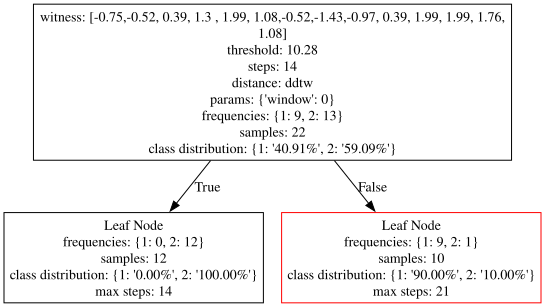

In [6]:
# Define the Node class
class Node:
    def __init__(self, witness, threshold, steps, class_distribution, all_classes,
                 distance_metric=None, distance_params=None, total_steps=0):
        self.witness = witness
        self.threshold = threshold
        self.steps = steps
        self.total_steps = total_steps  # Store the total steps taken to reach this node
        self.distance_metric = distance_metric  # Store the selected distance metric
        self.distance_params = distance_params  # Store the selected distance parameters
        self.class_distribution = self.calculate_probabilities(class_distribution, all_classes)
        self.probabilities = self.class_distribution
        self.samples = sum(class_distribution.values())
        self.raw_class_distribution = {k: class_distribution.get(k, 0) for k in all_classes}
        self.TrueChild = None
        self.FalseChild = None
        # Attributes for pruning
        self.is_leaf = False
        self.validation_class_distribution = {}
        self.validation_samples = 0
        self.static_error_rate = None
        self.backed_up_error_rate = None
        self.pruned = False

    def calculate_probabilities(self, class_distribution, all_classes):
        total = sum(class_distribution.values())
        probabilities = {k: class_distribution.get(k, 0) / total if total > 0 else 0 for k in all_classes}
        return probabilities

# Function for calculating the loss using entropy
def InformationGain(group1, group2):
    # Compute the entropy of a group
    def entropy(group):
        _, counts = np.unique(group, return_counts=True)
        probs = counts / len(group)
        return -sum(p * np.log2(p) for p in probs if p > 0)

    # Compute the information gain
    total_len = len(group1) + len(group2)
    entropy_before = entropy(np.concatenate((group1, group2)))
    entropy_after = (len(group1) * entropy(group1) + len(group2) * entropy(group2)) / total_len
    return entropy_before - entropy_after

# Function to calculate estimated error rates and perform pruning
def post_prune_tree(node, all_classes):
    if node.is_leaf:
        # Calculate estimated error rate for leaf node
        if node.validation_class_distribution:
            majority_class_count = node.validation_class_distribution.get(
                max(node.validation_class_distribution, key=node.validation_class_distribution.get, default=None), 0
            )
        else:
            majority_class_count = 0
        total = node.validation_samples
        if total > 0:
            node.static_error_rate = 1 - (majority_class_count / total)
        else:
            node.static_error_rate = 0  # No validation samples reached this node
        node.backed_up_error_rate = node.static_error_rate
    else:
        # Recursively prune child nodes
        post_prune_tree(node.TrueChild, all_classes)
        post_prune_tree(node.FalseChild, all_classes)
        # Calculate static error rate if we prune this node
        if node.validation_class_distribution:
            majority_class_count = node.validation_class_distribution.get(
                max(node.validation_class_distribution, key=node.validation_class_distribution.get, default=None), 0
            )
        else:
            majority_class_count = 0
        total = node.validation_samples
        if total > 0:
            node.static_error_rate = 1 - (majority_class_count / total)
        else:
            node.static_error_rate = 0  # No validation samples reached this node
        # Calculate backed-up error rate from children
        true_child = node.TrueChild
        false_child = node.FalseChild
        total_children = true_child.validation_samples + false_child.validation_samples
        if total_children > 0:
            node.backed_up_error_rate = (
                (true_child.validation_samples / total_children) * true_child.backed_up_error_rate +
                (false_child.validation_samples / total_children) * false_child.backed_up_error_rate
            )
        else:
            node.backed_up_error_rate = 0  # No validation samples in children
        # Decide whether to prune
        if node.static_error_rate <= node.backed_up_error_rate:
            # Prune the subtree
            node.TrueChild = None
            node.FalseChild = None
            node.is_leaf = True
            node.pruned = True
            node.backed_up_error_rate = node.static_error_rate
        else:
            node.pruned = False
            node.backed_up_error_rate = node.backed_up_error_rate

# Main training function for the tree model
def TS_Step_Tree_Train(X, Y, X_val, Y_val, maxstep, stepsize, maxd, mins, all_classes,
                       distance_functions,
                       allow_step_reuse=True, post_pruning=True, total_steps=0):
    def frequencies(Y):
        unique, counts = np.unique(Y, return_counts=True)
        return dict(zip(unique, counts))

    if len(set(Y)) == 1 or maxd == 0 or len(X) < mins or min(len(ts) for ts in X) < stepsize:
        node = Node(None, None, None, frequencies(Y), all_classes, total_steps=total_steps)
        node.is_leaf = True
        # Assign validation data to the leaf node
        node.validation_class_distribution = frequencies(Y_val)
        node.validation_samples = len(Y_val)
    else:
        real_maxstep = min(maxstep, min(len(ts) for ts in X))
        i = 1
        bestIg = 0
        best_witness = None
        best_threshold = None
        best_steps = None
        best_distance_metric = None
        best_distance_params = None
        while i * stepsize <= real_maxstep:
            X_subset = np.ascontiguousarray(X[:, 0:i * stepsize])
            # Find the best witness and split using different distance functions
            Ig, witness, threshold, distance_metric, distance_params = Find_Witness(
                X_subset, Y, distance_functions
            )
            if bestIg < Ig:
                bestIg = Ig
                best_witness = witness
                best_threshold = threshold
                best_steps = i * stepsize
                best_distance_metric = distance_metric
                best_distance_params = distance_params
            i += 1

        if bestIg == 0:
            node = Node(None, None, None, frequencies(Y), all_classes, total_steps=total_steps)
            node.is_leaf = True
            # Assign validation data to the leaf node
            node.validation_class_distribution = frequencies(Y_val)
            node.validation_samples = len(Y_val)
        else:
            node = Node(best_witness, best_threshold, best_steps, frequencies(Y), all_classes,
                        distance_metric=best_distance_metric, distance_params=best_distance_params,
                        total_steps=total_steps + best_steps)
            # Split the training data
            TrueIndexes = [i for i in range(len(X)) if aeon_distance(
                np.ascontiguousarray(best_witness),
                np.ascontiguousarray(X[i, 0:best_steps]),
                metric=best_distance_metric,
                **best_distance_params
            ) <= best_threshold]
            FalseIndexes = [i for i in range(len(X)) if i not in TrueIndexes]
            # Split the validation data
            TrueValIndexes = [i for i in range(len(X_val)) if aeon_distance(
                np.ascontiguousarray(best_witness),
                np.ascontiguousarray(X_val[i, 0:best_steps]),
                metric=best_distance_metric,
                **best_distance_params
            ) <= best_threshold]
            FalseValIndexes = [i for i in range(len(X_val)) if i not in TrueValIndexes]
            # Recursive calls for children
            node.TrueChild = TS_Step_Tree_Train(
                np.ascontiguousarray(X[TrueIndexes, best_steps + 1:]),
                Y[TrueIndexes],
                np.ascontiguousarray(X_val[TrueValIndexes, best_steps + 1:]),
                Y_val[TrueValIndexes],
                maxstep, stepsize, maxd - 1, mins, all_classes,
                distance_functions,
                allow_step_reuse, post_pruning=False,
                total_steps=node.total_steps
            )
            if allow_step_reuse:
                node.FalseChild = TS_Step_Tree_Train(
                    np.ascontiguousarray(X[FalseIndexes, :]),
                    Y[FalseIndexes],
                    np.ascontiguousarray(X_val[FalseValIndexes, :]),
                    Y_val[FalseValIndexes],
                    maxstep, stepsize, maxd - 1, mins, all_classes,
                    distance_functions,
                    allow_step_reuse, post_pruning=False,
                    total_steps=node.total_steps
                )
            else:
                node.FalseChild = TS_Step_Tree_Train(
                    np.ascontiguousarray(X[FalseIndexes, best_steps + 1:]),
                    Y[FalseIndexes],
                    np.ascontiguousarray(X_val[FalseValIndexes, best_steps + 1:]),
                    Y_val[FalseValIndexes],
                    maxstep, stepsize, maxd - 1, mins, all_classes,
                    distance_functions,
                    allow_step_reuse, post_pruning=False,
                    total_steps=node.total_steps
                )
            # Assign validation data to the node
            node.validation_class_distribution = frequencies(Y_val)
            node.validation_samples = len(Y_val)

    # Perform post-pruning if enabled
    if post_pruning:
        post_prune_tree(node, all_classes)

    return node

def Find_Witness(X_subset, Y, distance_functions):
    max_loss = 0
    best_witness = None
    best_threshold = None
    best_distance_metric = None
    best_distance_params = None

    for dist_func in distance_functions:
        metric = dist_func['metric']
        param_grid = dist_func.get('params', [{}])  # Default to [{}] if no params

        for params in param_grid:
            try:
                DM = aeon_pairwise_distance(X_subset, metric=metric, **params)
            except Exception as e:
                print(f"Error computing distances with metric {metric} and params {params}: {e}")
                continue
            for i in range(len(X_subset)):
                value, threshold = best_cut(i, Y, DM, InformationGain)
                if value > max_loss:
                    max_loss = value
                    best_witness = X_subset[i]
                    best_threshold = threshold
                    best_distance_metric = metric
                    best_distance_params = params

    return max_loss, best_witness, best_threshold, best_distance_metric, best_distance_params

def best_cut(idx, Y, DM, Loss):
    pairs = [(DM[j, idx], Y[j]) for j in range(len(Y))]
    pairs.sort(key=lambda x: x[0])
    if len(pairs) < 2:
        return 0, 0  # Cannot split
    loss_values = [Loss(
        np.array([p[1] for p in pairs[:j]]),
        np.array([p[1] for p in pairs[j:]])
    ) for j in range(1, len(Y))]
    j = np.argmax(loss_values)
    threshold = (pairs[j][0] + pairs[j - 1][0]) / 2

    return loss_values[j], threshold

def predict(node, x):
    if node.witness is None or node.is_leaf:
        return node.probabilities
    distance_metric = node.distance_metric
    distance_params = node.distance_params if node.distance_params else {}
    distance = aeon_distance(
        np.ascontiguousarray(node.witness),
        np.ascontiguousarray(x[0:node.steps]),
        metric=distance_metric,
        **distance_params
    )
    if distance <= node.threshold:
        if node.TrueChild is not None:
            return predict(node.TrueChild, x[node.steps:])
        else:
            return node.probabilities
    else:
        if node.FalseChild is not None:
            return predict(node.FalseChild, x[node.steps:])
        else:
            return node.probabilities
# New function to later calculate min, max, median and std of steps in leaf nodes
def collect_leaf_steps(node, steps_list):
    if node.is_leaf:
        if node.total_steps is not None:
            steps_list.append(node.total_steps)
    else:
        if node.TrueChild:
            collect_leaf_steps(node.TrueChild, steps_list)
        if node.FalseChild:
            collect_leaf_steps(node.FalseChild, steps_list)

# Visualize the tree using graphviz, highlighting pruned nodes in red and showing additional new statistics
def visualize_step_tree(node, all_classes, dot=None, root_steps=None):
    if dot is None:
        dot = graphviz.Digraph()
        root_steps = node.steps if node.steps is not None else 0

    steps_list = []
    collect_leaf_steps(node, steps_list)

    # Calculate the overall max steps
    overall_max_steps = max(steps_list) if steps_list else root_steps

    if node.is_leaf:
        if not node.class_distribution:
            node_label = 'Leaf Node\nNo Data'
        else:
            total = sum(node.raw_class_distribution.values())
            class_distribution = {k: (node.raw_class_distribution.get(k, 0) / total) * 100 for k in all_classes}
            max_steps = node.total_steps
            node_label = 'Leaf Node\nfrequencies: {}\nsamples: {}\nclass distribution: {}\nmax steps: {}'.format(
                node.raw_class_distribution,
                node.samples,
                {k: f'{v:.2f}%' for k, v in class_distribution.items()},
                max_steps
            )
    else:
        total = sum(node.raw_class_distribution.values())
        class_distribution = {k: (node.raw_class_distribution.get(k, 0) / total) * 100 for k in all_classes}
        # Convert witness to string with limited length to avoid clutter
        witness_str = np.array2string(node.witness, precision=2, separator=',', suppress_small=True, max_line_width=80)
        node_label = 'witness: {}\nthreshold: {:.2f}\nsteps: {}\ndistance: {}\nparams: {}\nfrequencies: {}\nsamples: {}\nclass distribution: {}'.format(
            witness_str,
            node.threshold,
            node.steps,
            node.distance_metric,
            node.distance_params,
            node.raw_class_distribution,
            node.samples,
            {k: f'{v:.2f}%' for k, v in class_distribution.items()}
        )

    # Highlight pruned nodes in red
    if node.pruned:
        dot.node(str(id(node)), label=node_label, color='red', shape='box')
    else:
        dot.node(str(id(node)), label=node_label, shape='box')

    if not node.is_leaf:
        if node.TrueChild:
            dot.edge(str(id(node)), str(id(node.TrueChild)), label='True')
            visualize_step_tree(node.TrueChild, all_classes, dot, root_steps)
        if node.FalseChild:
            dot.edge(str(id(node)), str(id(node.FalseChild)), label='False')
            visualize_step_tree(node.FalseChild, all_classes, dot, root_steps)
    return dot

# Training usage 
maxstep = maxstep
stepsize = stepsize
maxd = relative_max_depth
mins = relative_min_samples_leaf

# Combine all classes from training and validation sets
all_classes = np.unique(np.concatenate((Y_train, Y_validation)))

# Define the distance functions and parameter grids to test
distance_functions = [
    {'metric': 'euclidean', 'params': [{}]},
    {'metric': 'manhattan', 'params': [{}]},
    {'metric': 'squared', 'params': [{}]},
    {'metric': 'minkowski', 'params': [{'p': 1.0}, {'p': 3.0}]},
    {'metric': 'dtw', 'params': [{'window': None}, {'window': 0}, {'window': 0.25}, {'window': 0.5}, {'window': 0.75}, {'window': 1.0}, {'itakura_max_slope': None}, {'itakura_max_slope': 0.5}, {'itakura_max_slope': 1.0}]},
    {'metric': 'ddtw', 'params': [{'window': None}, {'window': 0}, {'window': 0.25}, {'window': 0.5}, {'window': 0.75}, {'window': 1.0}, {'itakura_max_slope': None}, {'itakura_max_slope': 0.5}, {'itakura_max_slope': 1.0}]},
    {'metric': 'wdtw', 'params': [{'g': 0.05}, {'g': 0.1}, {'g': 0.25}, {'itakura_max_slope': None}, {'itakura_max_slope': 0.5}, {'itakura_max_slope': 1.0}]},
    {'metric': 'wddtw', 'params': [{'g': 0.05}, {'g': 0.1}, {'g': 0.25}, {'itakura_max_slope': None}, {'itakura_max_slope': 0.5}, {'itakura_max_slope': 1.0}]},
    {'metric': 'lcss', 'params': [{'epsilon': 0.5}, {'epsilon': 1.0}, {'epsilon': 1.75}, {'epsilon': 3}]},
    {'metric': 'edr', 'params': [{'epsilon': 0.5}, {'epsilon': 1.0}, {'epsilon': 1.75}, {'epsilon': 3}]},
    {'metric': 'erp', 'params': [{'g': 0.0}, {'g': 0.5}, {'g': 1.0}]},
    {'metric': 'msm', 'params': [{'c': 0.01}, {'c': 0.1}, {'c': 1.0}, {'independent': True}, {'independent': False}]},
    {'metric': 'twe', 'params': [{'nu': 0.001, 'lambda': 1.0}, {'nu': 0.001, 'lambda': 1.5}, {'nu': 0.001, 'lambda': 2.0}]},
    {'metric': 'adtw', 'params': [{'warp_penalty': 0.5}, {'warp_penalty': 1.0}, {'warp_penalty': 2.0}]},
    {'metric': 'sbd', 'params': [{'standardize': True}, {'standardize': False}]},
    {'metric': 'shape_dtw', 'params': [{'reach': 10}, {'reach': 30}, {'reach': 50},
    ]}
]

# Train the model with validation data and post-pruning option
train_example = TS_Step_Tree_Train(
    X_train, Y_train, X_validation, Y_validation,
    maxstep, stepsize, maxd, mins,
    all_classes, distance_functions,
    allow_step_reuse=True, post_pruning=True
)

# Collect the steps from all leaf nodes
steps_list = []
collect_leaf_steps(train_example, steps_list)

# Calculate the statistics
min_steps = min(steps_list) if steps_list else 0
max_steps = max(steps_list) if steps_list else 0
median_steps = np.median(steps_list) if steps_list else 0
std_steps = np.std(steps_list) if steps_list else 0

# Print the statistics
print(f"Minimum steps: {min_steps}")
print(f"Median steps: {median_steps}")
print(f"Maximum steps: {max_steps}")
print(f"Standard deviation of steps: {std_steps:.2f}")

# Visualize the pruned tree
dot = visualize_step_tree(train_example, all_classes)
dot.render(f'{dataset}_ts_step_tree', format='pdf', cleanup=True)
dot

## Evaluation metrics and ROC curve for Univariate tree

Overall Accuracy on test set: 81.01

Classification Report:
              precision    recall  f1-score   support

           1       0.75      0.75      0.75       365
           2       0.84      0.85      0.85       588

    accuracy                           0.81       953
   macro avg       0.80      0.80      0.80       953
weighted avg       0.81      0.81      0.81       953

Cohen's Kappa: 0.60
Matthews Correlation Coefficient (MCC): 0.60

Per-Class Metrics:
   Precision    Recall  F1-Score  Accuracy  Cohen's Kappa       MCC
1   0.754144  0.747945  0.751032  0.747945       0.597516  0.597529
2   0.844332  0.848639  0.846480  0.848639       0.597516  0.597529


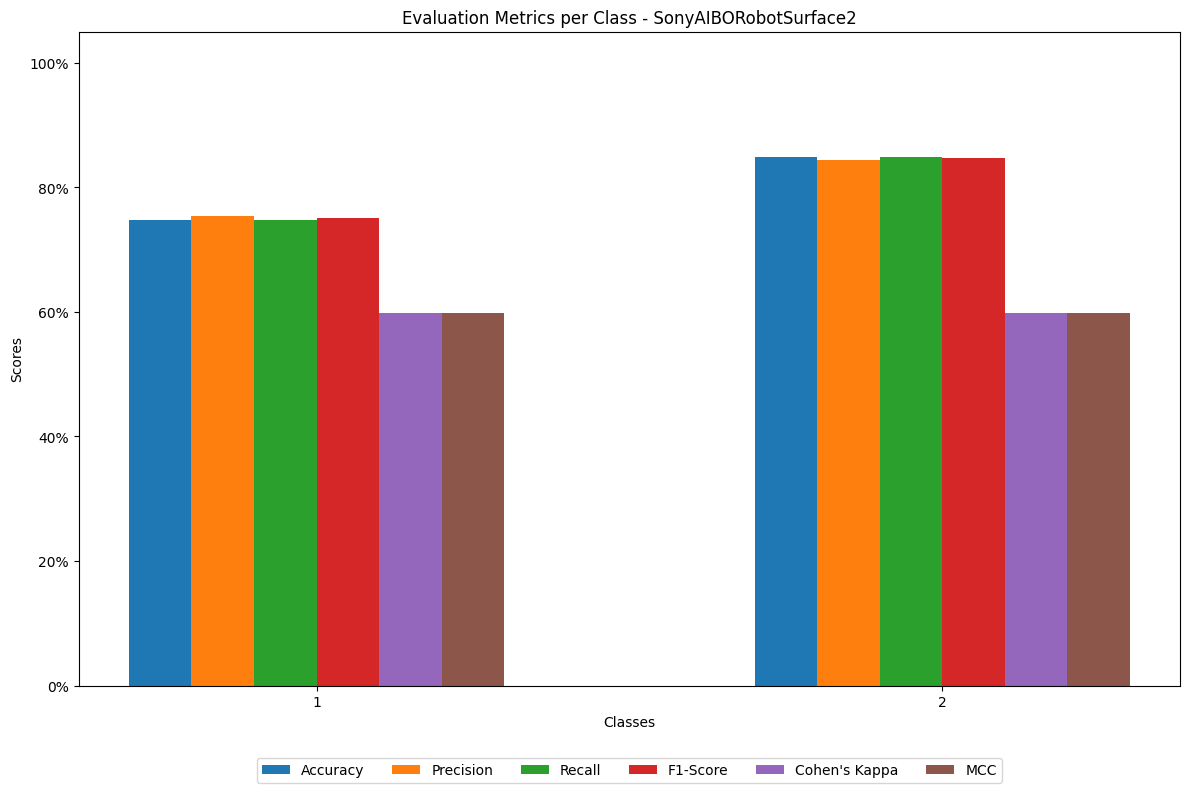

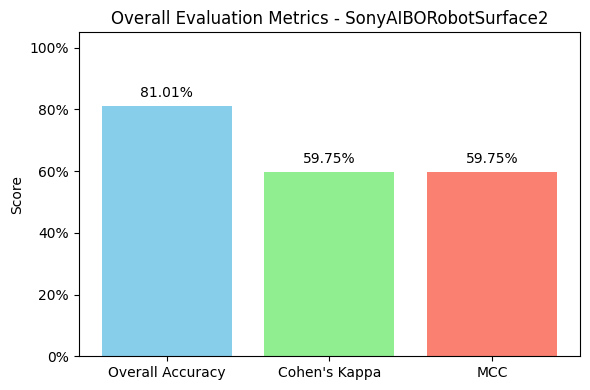

One-vs-Rest (OvR) Scheme


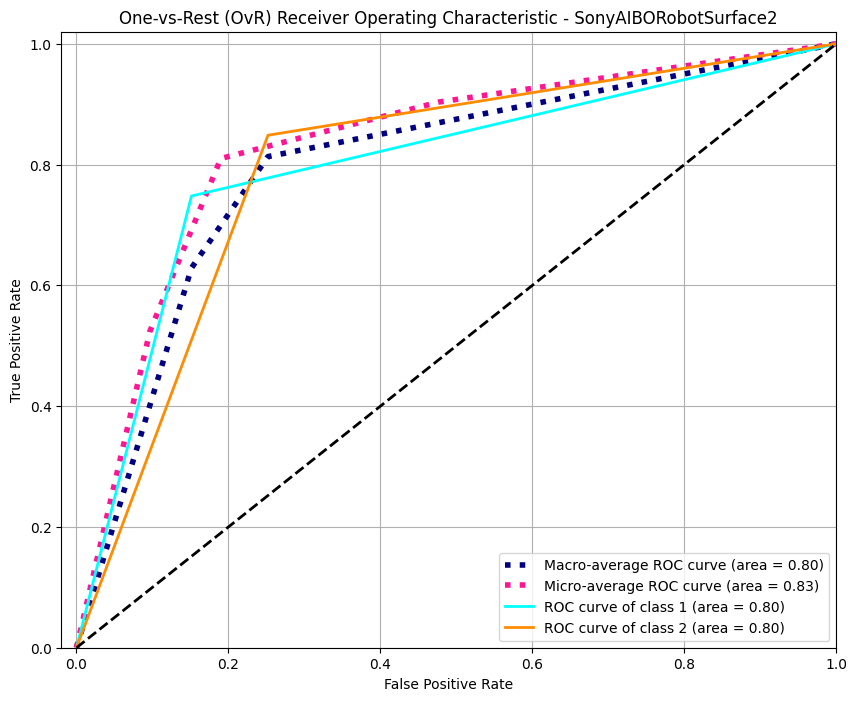

Binary classification detected. Skipping OvO plot as it's equivalent to OvR.


In [7]:
# Evaluate the tree on the test set
def evaluate_model(node, X_test, Y_test, class_names):
    correct = 0
    total = len(Y_test)
    y_true = []
    y_pred = []
    for x, y_t in zip(X_test, Y_test):
        probabilities = predict(node, x)
        y_p = max(probabilities, key=probabilities.get)
        y_true.append(y_t)
        y_pred.append(y_p)
        if y_p == y_t:
            correct += 1
    accuracy = correct / total
    print(f"Overall Accuracy on test set: {accuracy * 100:.2f}")
    
    # Generate classification report
    report = classification_report(y_true, y_pred, labels=class_names, output_dict=True, zero_division='warn')
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, labels=class_names, zero_division='warn'))
    
    # Calculate Cohen's Kappa
    kappa = cohen_kappa_score(y_true, y_pred)
    print(f"Cohen's Kappa: {kappa:.2f}")
    
    # Calculate Matthews Correlation Coefficient (MCC)
    mcc = matthews_corrcoef(y_true, y_pred)
    print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")
    
    # Calculate per-class accuracy
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
    
    # Prepare data for visualization
    metrics_df = pd.DataFrame(index=class_names)
    metrics_df['Precision'] = [report[str(cls)]['precision'] for cls in class_names]
    metrics_df['Recall'] = [report[str(cls)]['recall'] for cls in class_names]
    metrics_df['F1-Score'] = [report[str(cls)]['f1-score'] for cls in class_names]
    metrics_df['Accuracy'] = per_class_accuracy
    # Kappa and MCC are overall metrics; we can replicate them for each class for visualization purposes
    metrics_df["Cohen's Kappa"] = kappa
    metrics_df['MCC'] = mcc
    
    # Display the DataFrame
    print("\nPer-Class Metrics:")
    print(metrics_df)
    
    # Plot the metrics
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', "Cohen's Kappa", 'MCC']
    num_metrics = len(metrics)
    num_classes = len(class_names)
    bar_width = 0.1
    index = np.arange(num_classes)
    
    plt.figure(figsize=(12, 8))
    
    for i, metric in enumerate(metrics):
        plt.bar(index + i * bar_width, metrics_df[metric], bar_width, label=metric)
    
    plt.xlabel('Classes')
    plt.ylabel('Scores')
    plt.title(f'Evaluation Metrics per Class - {dataset}')
    plt.xticks(index + bar_width * (num_metrics - 1) / 2, class_names)
    plt.ylim(0, 1.05)
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=num_metrics)
    
    # Format y-axis as percentages
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{int(y * 100)}%'))
    
    plt.tight_layout()
    plt.savefig(f'{dataset}_evaluation_metrics_per_class.pdf')
    plt.show()
    
    # Also, plot overall metrics separately if desired
    overall_metrics = {
        'Overall Accuracy': accuracy,
        "Cohen's Kappa": kappa,
        'MCC': mcc
    }
    plt.figure(figsize=(6, 4))
    bars = plt.bar(overall_metrics.keys(), overall_metrics.values(), color=['skyblue', 'lightgreen', 'salmon'])
    plt.ylabel('Score')
    plt.title(f'Overall Evaluation Metrics - {dataset}')
    plt.ylim(0, 1.05)
    
    # Adding the scores on top of the bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval * 100:.2f}%', ha='center', va='bottom')
    
    # Format y-axis as percentages
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{int(y * 100)}%'))
    
    plt.tight_layout()
    plt.savefig(f'{dataset}_overall_evaluation_metrics.pdf')
    plt.show()

# Define class names (labels)
class_names = sorted(np.unique(np.concatenate((Y_train, Y_validation, Y_test))))

# Call the function to evaluate the model and plot the metrics
evaluate_model(train_example, X_test, Y_test, class_names)

##################################################<<<ROC CURVES>>>##################################################

# 'all_classes', 'train_example', 'X_test', 'Y_test', and 'predict' must be defined.

# Combine all classes from training, validation, and test sets
all_classes = np.unique(np.concatenate((Y_train, Y_validation, Y_test)))
n_classes = len(all_classes)

# Ensure that 'all_classes' is sorted to maintain consistent ordering
all_classes = np.sort(all_classes)

# Binarize the labels
if n_classes == 2:
    # Manually create a binary label matrix with two columns for binary classification
    Y_test_bin = np.zeros((len(Y_test), n_classes))
    for i, class_label in enumerate(all_classes):
        Y_test_bin[:, i] = (Y_test == class_label).astype(int)
else:
    # For multiclass classification
    Y_test_bin = label_binarize(Y_test, classes=all_classes)

# Generate predictions for the test data
probabilities_train_example = []
for x in X_test:
    prob = predict(train_example, x)
    # Ensure the probabilities are in the same order as 'all_classes'
    probabilities = [prob.get(cls, 0) for cls in all_classes]
    probabilities_train_example.append(probabilities)

# Convert probabilities to a 2D array
probabilities_train_example = np.array(probabilities_train_example)

# One-vs-Rest (OvR) Scheme
print("One-vs-Rest (OvR) Scheme")

# Initialize dictionaries to hold fpr, tpr, and roc_auc for each class
fpr_ovr = dict()
tpr_ovr = dict()
roc_auc_ovr = dict()

# Compute ROC curve and ROC area for each class
for i in range(n_classes):
    fpr_ovr[i], tpr_ovr[i], _ = roc_curve(Y_test_bin[:, i], probabilities_train_example[:, i])
    roc_auc_ovr[i] = auc(fpr_ovr[i], tpr_ovr[i])

# Compute micro-average ROC curve and ROC area
fpr_ovr["micro"], tpr_ovr["micro"], _ = roc_curve(Y_test_bin.ravel(), probabilities_train_example.ravel())
roc_auc_ovr["micro"] = auc(fpr_ovr["micro"], tpr_ovr["micro"])

# Compute macro-average ROC curve and ROC area
# First aggregate all false positive rates
all_fpr_ovr = np.unique(np.concatenate([fpr_ovr[i] for i in range(n_classes)]))

# Then interpolate all ROC curves at these points
mean_tpr_ovr = np.zeros_like(all_fpr_ovr)
for i in range(n_classes):
    mean_tpr_ovr += np.interp(all_fpr_ovr, fpr_ovr[i], tpr_ovr[i])

# Finally average it and compute AUC
mean_tpr_ovr /= n_classes

fpr_ovr["macro"] = all_fpr_ovr
tpr_ovr["macro"] = mean_tpr_ovr
roc_auc_ovr["macro"] = auc(fpr_ovr["macro"], tpr_ovr["macro"])

# Plot all OvR ROC curves
plt.figure(figsize=(10, 8))

# Plot macro-average ROC curve
plt.plot(fpr_ovr["macro"], tpr_ovr["macro"],
         label='Macro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc_ovr["macro"]),
         color='navy', linestyle=':', linewidth=4)

# Plot micro-average ROC curve
plt.plot(fpr_ovr["micro"], tpr_ovr["micro"],
         label='Micro-average ROC curve (area = {0:0.2f})'
               ''.format(roc_auc_ovr["micro"]),
         color='deeppink', linestyle=':', linewidth=4)

# Plot ROC curves for each class
colors = ['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple', 'brown', 'olive', 'cyan', 'magenta']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr_ovr[i], tpr_ovr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(all_classes[i], roc_auc_ovr[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'One-vs-Rest (OvR) Receiver Operating Characteristic - {dataset}')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig(f'{dataset}_roc_curve_ovr.pdf')
plt.show()

# One-vs-One (OvO) Scheme
if n_classes > 2:
    print("One-vs-One (OvO) Scheme")

    # Initialize lists to hold fpr, tpr, and roc_auc for each pair
    fpr_ovo = dict()
    tpr_ovo = dict()
    roc_auc_ovo = dict()

    # Generate all pairs of classes
    pair_indices = list(combinations(range(n_classes), 2))

    # Initialize lists for macro-average and micro-average computation
    tprs_ovo = []
    aucs_ovo = []
    mean_fpr_ovo = np.linspace(0, 1, 100)

    # Lists to collect all true labels and scores for micro-average
    all_true_labels = []
    all_scores = []

    for (i, j) in pair_indices:
        # Create a mask for the two classes
        mask = np.logical_or(Y_test == all_classes[i], Y_test == all_classes[j])
        Y_test_pair = Y_test[mask]
        if len(np.unique(Y_test_pair)) < 2:
            continue  # Skip if only one class is present
        Y_test_bin_pair = (Y_test_pair == all_classes[j]).astype(int)
        probabilities_pair = probabilities_train_example[mask][:, [i, j]]
        # Use probabilities for the positive class (all_classes[j])
        y_score = probabilities_pair[:, 1]
        fpr, tpr, _ = roc_curve(Y_test_bin_pair, y_score)
        roc_auc = auc(fpr, tpr)
        fpr_ovo[(i, j)] = fpr
        tpr_ovo[(i, j)] = tpr
        roc_auc_ovo[(i, j)] = roc_auc
        # Interpolate tpr at mean_fpr_ovo for macro-average
        interp_tpr = np.interp(mean_fpr_ovo, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs_ovo.append(interp_tpr)
        aucs_ovo.append(roc_auc)
        # Collect data for micro-average
        all_true_labels.extend(Y_test_bin_pair)
        all_scores.extend(y_score)

    # Compute micro-average ROC curve and ROC area
    all_true_labels = np.array(all_true_labels)
    all_scores = np.array(all_scores)
    fpr_ovo["micro"], tpr_ovo["micro"], _ = roc_curve(all_true_labels, all_scores)
    roc_auc_ovo["micro"] = auc(fpr_ovo["micro"], tpr_ovo["micro"])

    # Compute macro-average ROC curve and ROC area for OvO
    mean_tpr_ovo = np.mean(tprs_ovo, axis=0)
    mean_tpr_ovo[-1] = 1.0
    roc_auc_ovo["macro"] = auc(mean_fpr_ovo, mean_tpr_ovo)

    # Plot all OvO ROC curves
    plt.figure(figsize=(10, 8))

    # Plot macro-average ROC curve
    plt.plot(mean_fpr_ovo, mean_tpr_ovo,
             label='Macro-average ROC curve (area = {0:0.2f})'
                   ''.format(roc_auc_ovo["macro"]),
             color='navy', linestyle=':', linewidth=4)

    # Plot micro-average ROC curve
    plt.plot(fpr_ovo["micro"], tpr_ovo["micro"],
             label='Micro-average ROC curve (area = {0:0.2f})'
                   ''.format(roc_auc_ovo["micro"]),
             color='deeppink', linestyle=':', linewidth=4)

    # Plot ROC curves for each pair
    for (i, j) in pair_indices:
        if (i, j) in fpr_ovo:
            plt.plot(fpr_ovo[(i, j)], tpr_ovo[(i, j)], lw=1.5,
                     label='ROC curve between classes {0} and {1} (area = {2:0.2f})'
                     ''.format(all_classes[i], all_classes[j], roc_auc_ovo[(i, j)]))

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([-0.02, 1.0])
    plt.ylim([0.0, 1.02])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'One-vs-One (OvO) Receiver Operating Characteristic - {dataset}')
    plt.legend(loc="lower right", fontsize='small')
    plt.grid(True)
    plt.savefig(f'{dataset}_roc_curve_ovo.pdf')
    plt.show()
else:
    print("Binary classification detected. Skipping OvO plot as it's equivalent to OvR.")



## Random Forest for Univariate dataset

Training tree 1/1
Tree 1 statistics:
  Minimum steps: 7
  Median steps: 7.0
  Maximum steps: 7
  Standard deviation of steps: 0.00

Overall statistics across all trees:
Minimum steps across all leaf nodes: 7
Median steps across all leaf nodes: 7.0
Maximum steps across all leaf nodes: 7
Standard deviation of steps across all leaf nodes: 0.00
Overall Accuracy on test set: 38.30%

Classification Report:
              precision    recall  f1-score   support

           1       0.38      1.00      0.55       365
           2       0.00      0.00      0.00       588

    accuracy                           0.38       953
   macro avg       0.19      0.50      0.28       953
weighted avg       0.15      0.38      0.21       953

Cohen's Kappa: 0.00
Matthews Correlation Coefficient (MCC): 0.00

Per-Class Metrics:
   Precision  Recall  F1-Score  Accuracy  Cohen's Kappa  MCC
1   0.383001     1.0  0.553869       1.0            0.0  0.0
2   0.000000     0.0  0.000000       0.0            0.0  0.0


/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packag

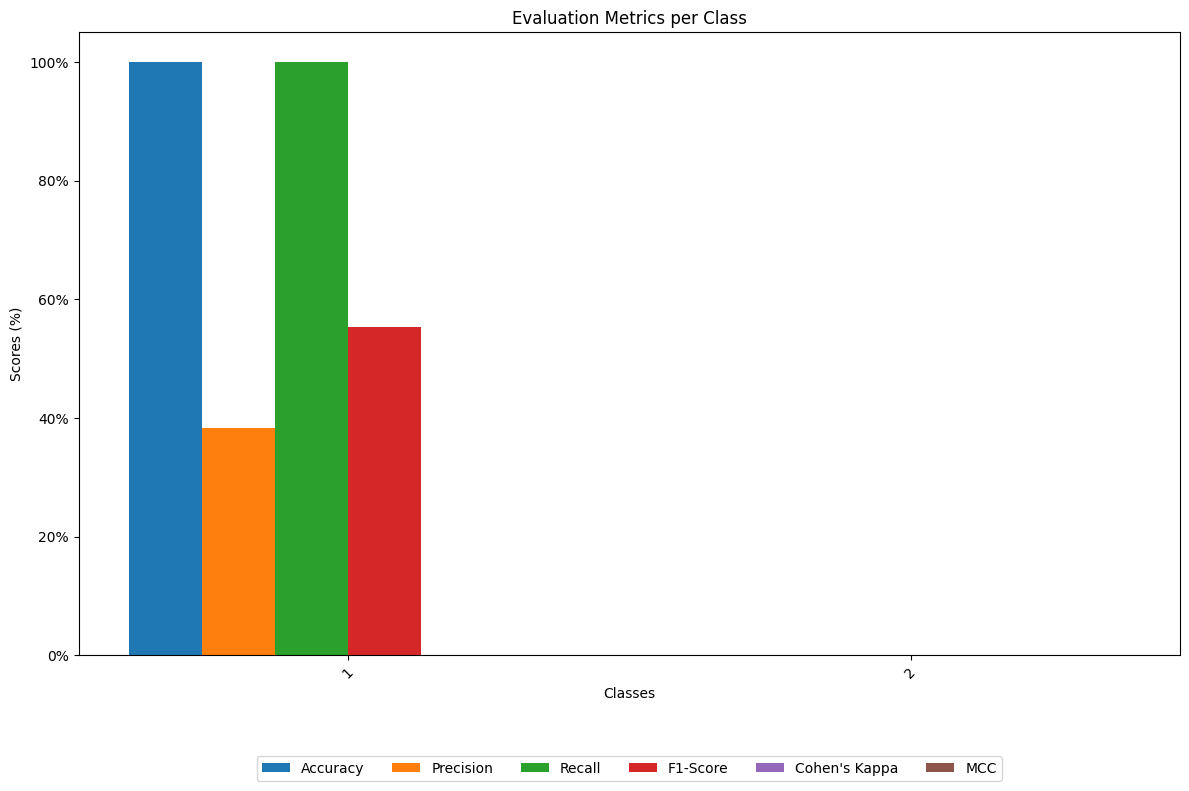

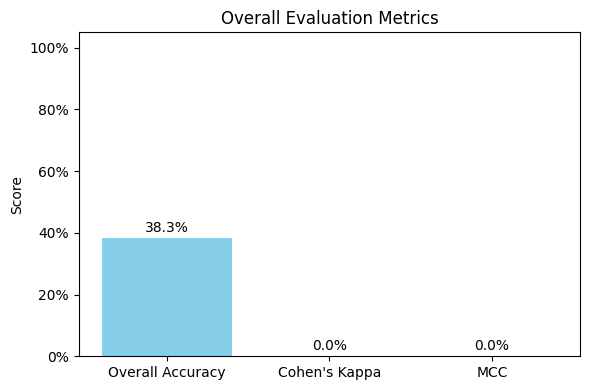

One-vs-Rest (OvR) Scheme


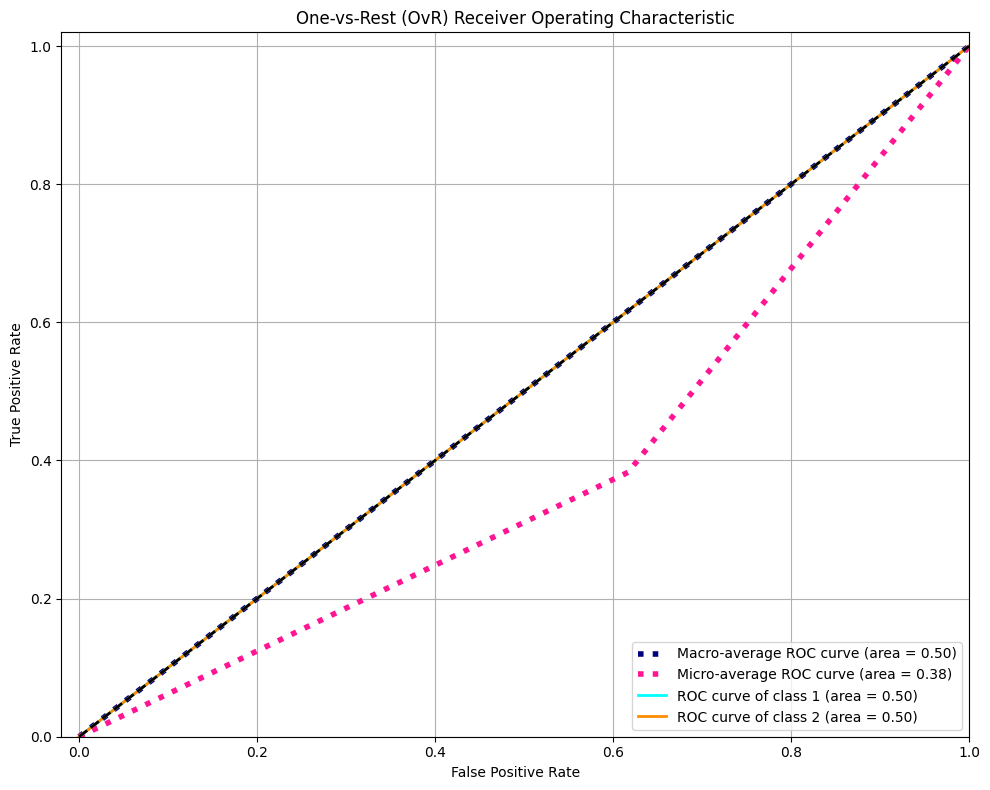

Binary classification detected. Skipping OvO plot as it's equivalent to OvR.


In [8]:
# Define the Node class with total_steps attribute
class Node:
    def __init__(
        self,
        witness,
        threshold,
        steps,
        class_distribution,
        all_classes,
        distance_metric=None,
        distance_params=None,
        total_steps=0,
    ):
        self.witness = witness
        self.threshold = threshold
        self.steps = steps
        self.total_steps = total_steps  # Store the total steps taken to reach this node
        self.distance_metric = distance_metric  # Store the selected distance metric
        self.distance_params = distance_params  # Store the selected distance parameters
        self.class_distribution = self.calculate_probabilities(
            class_distribution, all_classes
        )
        self.probabilities = self.class_distribution
        self.samples = sum(class_distribution.values())
        self.raw_class_distribution = {
            k: class_distribution.get(k, 0) for k in all_classes
        }
        self.TrueChild = None
        self.FalseChild = None
        # Attributes for pruning
        self.is_leaf = False
        self.validation_class_distribution = {}
        self.validation_samples = 0
        self.static_error_rate = None
        self.backed_up_error_rate = None
        self.pruned = False

    def calculate_probabilities(self, class_distribution, all_classes):
        total = sum(class_distribution.values())
        probabilities = {
            k: class_distribution.get(k, 0) / total if total > 0 else 0
            for k in all_classes
        }
        return probabilities

# Function for calculating the loss using entropy
def InformationGain(group1, group2):
    # Compute the entropy of a group
    def entropy(group):
        _, counts = np.unique(group, return_counts=True)
        probs = counts / len(group)
        return -sum(p * np.log2(p) for p in probs if p > 0)

    # Compute the information gain
    total_len = len(group1) + len(group2)
    entropy_before = entropy(np.concatenate((group1, group2)))
    entropy_after = (
        (len(group1) * entropy(group1) + len(group2) * entropy(group2)) / total_len
    )
    return entropy_before - entropy_after

# Function to calculate estimated error rates and perform pruning
def post_prune_tree(node, all_classes):
    if node.is_leaf:
        # Calculate estimated error rate for leaf node
        if node.validation_class_distribution:
            majority_class_count = node.validation_class_distribution.get(
                max(
                    node.validation_class_distribution,
                    key=node.validation_class_distribution.get,
                    default=None,
                ),
                0,
            )
        else:
            majority_class_count = 0
        total = node.validation_samples
        if total > 0:
            node.static_error_rate = 1 - (majority_class_count / total)
        else:
            node.static_error_rate = 0  # No validation samples reached this node
        node.backed_up_error_rate = node.static_error_rate
    else:
        # Recursively prune child nodes
        post_prune_tree(node.TrueChild, all_classes)
        post_prune_tree(node.FalseChild, all_classes)
        # Calculate static error rate if we prune this node
        if node.validation_class_distribution:
            majority_class_count = node.validation_class_distribution.get(
                max(
                    node.validation_class_distribution,
                    key=node.validation_class_distribution.get,
                    default=None,
                ),
                0,
            )
        else:
            majority_class_count = 0
        total = node.validation_samples
        if total > 0:
            node.static_error_rate = 1 - (majority_class_count / total)
        else:
            node.static_error_rate = 0  # No validation samples reached this node
        # Calculate backed-up error rate from children
        true_child = node.TrueChild
        false_child = node.FalseChild
        total_children = true_child.validation_samples + false_child.validation_samples
        if total_children > 0:
            node.backed_up_error_rate = (
                (true_child.validation_samples / total_children)
                * true_child.backed_up_error_rate
                + (false_child.validation_samples / total_children)
                * false_child.backed_up_error_rate
            )
        else:
            node.backed_up_error_rate = 0  # No validation samples in children
        # Decide whether to prune
        if node.static_error_rate <= node.backed_up_error_rate:
            # Prune the subtree
            node.TrueChild = None
            node.FalseChild = None
            node.is_leaf = True
            node.pruned = True
            node.backed_up_error_rate = node.static_error_rate
        else:
            node.pruned = False
            node.backed_up_error_rate = node.backed_up_error_rate

# Main training function for the tree model
def TS_Step_Tree_Train(
    X,
    Y,
    X_val,
    Y_val,
    maxstep,
    stepsize,
    maxd,
    mins,
    all_classes,
    distance_functions,
    allow_step_reuse=True,
    post_pruning=True,
    total_steps=0,
):
    def frequencies(Y):
        unique, counts = np.unique(Y, return_counts=True)
        return dict(zip(unique, counts))

    if (
        len(set(Y)) == 1
        or maxd == 0
        or len(X) < mins
        or min(len(ts) for ts in X) < stepsize
    ):
        node = Node(None, None, None, frequencies(Y), all_classes, total_steps=total_steps)
        node.is_leaf = True
        # Assign validation data to the leaf node
        node.validation_class_distribution = frequencies(Y_val)
        node.validation_samples = len(Y_val)
    else:
        real_maxstep = min(maxstep, min(len(ts) for ts in X))
        i = 1
        bestIg = 0
        best_witness = None
        best_threshold = None
        best_steps = None
        best_distance_metric = None
        best_distance_params = None
        while i * stepsize <= real_maxstep:
            X_subset = np.ascontiguousarray([ts[: i * stepsize] for ts in X])
            # Find the best witness and split using different distance functions
            Ig, witness, threshold, distance_metric, distance_params = Find_Witness(
                X_subset, Y, distance_functions
            )
            if bestIg < Ig:
                bestIg = Ig
                best_witness = witness
                best_threshold = threshold
                best_steps = i * stepsize
                best_distance_metric = distance_metric
                best_distance_params = distance_params
            i += 1

        if bestIg == 0:
            node = Node(None, None, None, frequencies(Y), all_classes, total_steps=total_steps)
            node.is_leaf = True
            # Assign validation data to the leaf node
            node.validation_class_distribution = frequencies(Y_val)
            node.validation_samples = len(Y_val)
        else:
            node = Node(
                best_witness,
                best_threshold,
                best_steps,
                frequencies(Y),
                all_classes,
                distance_metric=best_distance_metric,
                distance_params=best_distance_params,
                total_steps=total_steps + best_steps,
            )
            # Split the training data
            TrueIndexes = [
                idx
                for idx in range(len(X))
                if aeon_distance(
                    np.ascontiguousarray(best_witness),
                    np.ascontiguousarray(X[idx][: best_steps]),
                    metric=best_distance_metric,
                    **best_distance_params,
                )
                <= best_threshold
            ]
            FalseIndexes = [idx for idx in range(len(X)) if idx not in TrueIndexes]
            # Split the validation data
            TrueValIndexes = [
                idx
                for idx in range(len(X_val))
                if aeon_distance(
                    np.ascontiguousarray(best_witness),
                    np.ascontiguousarray(X_val[idx][: best_steps]),
                    metric=best_distance_metric,
                    **best_distance_params,
                )
                <= best_threshold
            ]
            FalseValIndexes = [idx for idx in range(len(X_val)) if idx not in TrueValIndexes]
            # Recursive calls for children
            node.TrueChild = TS_Step_Tree_Train(
                [X[idx][best_steps:] for idx in TrueIndexes],
                Y[TrueIndexes],
                [X_val[idx][best_steps:] for idx in TrueValIndexes],
                Y_val[TrueValIndexes],
                maxstep,
                stepsize,
                maxd - 1,
                mins,
                all_classes,
                distance_functions,
                allow_step_reuse,
                post_pruning=False,
                total_steps=node.total_steps,
            )
            if allow_step_reuse:
                node.FalseChild = TS_Step_Tree_Train(
                    [X[idx] for idx in FalseIndexes],
                    Y[FalseIndexes],
                    [X_val[idx] for idx in FalseValIndexes],
                    Y_val[FalseValIndexes],
                    maxstep,
                    stepsize,
                    maxd - 1,
                    mins,
                    all_classes,
                    distance_functions,
                    allow_step_reuse,
                    post_pruning=False,
                    total_steps=node.total_steps,
                )
            else:
                node.FalseChild = TS_Step_Tree_Train(
                    [X[idx][best_steps + 1 :] for idx in FalseIndexes],
                    Y[FalseIndexes],
                    [X_val[idx][best_steps + 1 :] for idx in FalseValIndexes],
                    Y_val[FalseValIndexes],
                    maxstep,
                    stepsize,
                    maxd - 1,
                    mins,
                    all_classes,
                    distance_functions,
                    allow_step_reuse,
                    post_pruning=False,
                    total_steps=node.total_steps,
                )
            # Assign validation data to the node
            node.validation_class_distribution = frequencies(Y_val)
            node.validation_samples = len(Y_val)

    # Perform post-pruning if enabled
    if post_pruning:
        post_prune_tree(node, all_classes)

    return node

def Find_Witness(X_subset, Y, distance_functions):
    max_loss = 0
    best_witness = None
    best_threshold = None
    best_distance_metric = None
    best_distance_params = None

    for dist_func in distance_functions:
        metric = dist_func['metric']
        param_grid = dist_func.get('params', [{}])  # Default to [{}] if no params

        for params in param_grid:
            try:
                DM = aeon_pairwise_distance(X_subset, metric=metric, **params)
            except Exception as e:
                print(f"Error computing distances with metric {metric} and params {params}: {e}")
                continue
            for i in range(len(X_subset)):
                value, threshold = best_cut(i, Y, DM, InformationGain)
                if value > max_loss:
                    max_loss = value
                    best_witness = X_subset[i]
                    best_threshold = threshold
                    best_distance_metric = metric
                    best_distance_params = params

    return max_loss, best_witness, best_threshold, best_distance_metric, best_distance_params

def best_cut(idx, Y, DM, Loss):
    pairs = [(DM[j, idx], Y[j]) for j in range(len(Y))]
    pairs.sort(key=lambda x: x[0])
    if len(pairs) < 2:
        return 0, 0  # Cannot split
    loss_values = [
        Loss(
            np.array([p[1] for p in pairs[:j]]),
            np.array([p[1] for p in pairs[j:]]),
        )
        for j in range(1, len(Y))
    ]
    j = np.argmax(loss_values)
    threshold = (pairs[j][0] + pairs[j - 1][0]) / 2

    return loss_values[j], threshold

def predict(node, x):
    if node.witness is None or node.is_leaf:
        return node.probabilities
    distance_metric = node.distance_metric
    distance_params = node.distance_params if node.distance_params else {}
    distance = aeon_distance(
        np.ascontiguousarray(node.witness),
        np.ascontiguousarray(x[: node.steps]),
        metric=distance_metric,
        **distance_params,
    )
    if distance <= node.threshold:
        if node.TrueChild is not None:
            return predict(node.TrueChild, x[node.steps:])
        else:
            return node.probabilities
    else:
        if node.FalseChild is not None:
            return predict(node.FalseChild, x[node.steps:])
        else:
            return node.probabilities

# New function to collect steps from leaf nodes
def collect_leaf_steps(node, steps_list):
    if node.is_leaf:
        if node.total_steps is not None:
            steps_list.append(node.total_steps)
    else:
        if node.TrueChild:
            collect_leaf_steps(node.TrueChild, steps_list)
        if node.FalseChild:
            collect_leaf_steps(node.FalseChild, steps_list)

# Implement the Random Forest
class RandomForest:
    def __init__(
        self,
        n_trees,
        maxstep,
        stepsize,
        maxd,
        mins,
        distance_functions,
        allow_step_reuse=True,
        post_pruning=True,
    ):
        self.n_trees = n_trees
        self.maxstep = maxstep
        self.stepsize = stepsize
        self.maxd = maxd
        self.mins = mins
        self.allow_step_reuse = allow_step_reuse
        self.post_pruning = post_pruning
        self.distance_functions = distance_functions
        self.trees = []
        self.all_classes = None
        self.all_steps_stats = {
            'min_steps': [],
            'median_steps': [],
            'max_steps': [],
            'std_steps': [],
        }

    def fit(self, X, Y):
        self.all_classes = np.unique(Y)
        n_samples = len(X)
        overall_steps_list = []  # Collect steps from all trees
        # Build each tree
        for i in range(self.n_trees):
            print(f"Training tree {i + 1}/{self.n_trees}")
            # Bootstrap sampling
            indices = np.random.choice(n_samples, n_samples, replace=True)
            oob_indices = [idx for idx in range(n_samples) if idx not in indices]
            X_bootstrap = [X[idx] for idx in indices]
            Y_bootstrap = Y[indices]
            X_oob = [X[idx] for idx in oob_indices]
            Y_oob = Y[oob_indices]
            # Train the tree
            tree = TS_Step_Tree_Train(
                X_bootstrap,
                Y_bootstrap,
                X_oob,
                Y_oob,
                self.maxstep,
                self.stepsize,
                self.maxd,
                self.mins,
                self.all_classes,
                self.distance_functions,
                self.allow_step_reuse,
                self.post_pruning,
            )
            self.trees.append(tree)
            # Collect steps from leaf nodes of this tree
            tree_steps_list = []
            collect_leaf_steps(tree, tree_steps_list)
            overall_steps_list.extend(tree_steps_list)
            # Calculate statistics for this tree
            if tree_steps_list:
                min_steps_tree = min(tree_steps_list)
                max_steps_tree = max(tree_steps_list)
                median_steps_tree = np.median(tree_steps_list)
                std_steps_tree = np.std(tree_steps_list)
            else:
                min_steps_tree = max_steps_tree = median_steps_tree = std_steps_tree = 0
            # Append tree-specific stats
            self.all_steps_stats['min_steps'].append(min_steps_tree)
            self.all_steps_stats['median_steps'].append(median_steps_tree)
            self.all_steps_stats['max_steps'].append(max_steps_tree)
            self.all_steps_stats['std_steps'].append(std_steps_tree)
            print(f"Tree {i + 1} statistics:")
            print(f"  Minimum steps: {min_steps_tree}")
            print(f"  Median steps: {median_steps_tree}")
            print(f"  Maximum steps: {max_steps_tree}")
            print(f"  Standard deviation of steps: {std_steps_tree:.2f}")

        # Calculate overall statistics across all trees
        if overall_steps_list:
            min_steps = min(overall_steps_list)
            max_steps = max(overall_steps_list)
            median_steps = np.median(overall_steps_list)
            std_steps = np.std(overall_steps_list)
        else:
            min_steps = max_steps = median_steps = std_steps = 0

        print("\nOverall statistics across all trees:")
        print(f"Minimum steps across all leaf nodes: {min_steps}")
        print(f"Median steps across all leaf nodes: {median_steps}")
        print(f"Maximum steps across all leaf nodes: {max_steps}")
        print(f"Standard deviation of steps across all leaf nodes: {std_steps:.2f}")

    def predict_proba(self, x):
        # Aggregate probabilities from all trees
        probabilities_list = []
        for tree in self.trees:
            probabilities = predict(tree, x)
            probabilities_list.append(probabilities)
        # Average the probabilities
        avg_probabilities = {}
        for cls in self.all_classes:
            avg_probabilities[cls] = np.mean(
                [prob.get(cls, 0) for prob in probabilities_list]
            )
        return avg_probabilities

    def predict(self, x):
        avg_probabilities = self.predict_proba(x)
        predicted_class = max(avg_probabilities, key=avg_probabilities.get)
        return predicted_class

    def evaluate(self, X_test, Y_test, class_names):
        y_true, y_pred = [], []
        probabilities_list = []  # For ROC curves
        for x, y_t in zip(X_test, Y_test):
            prob = self.predict_proba(x)
            y_p = max(prob, key=prob.get)
            y_true.append(y_t)
            y_pred.append(y_p)
            # Ensure the probabilities are in the same order as 'class_names'
            probabilities = [prob.get(cls, 0) for cls in class_names]
            probabilities_list.append(probabilities)
        # Compute overall accuracy
        correct = sum(1 for y_t, y_p in zip(y_true, y_pred) if y_t == y_p)
        total = len(Y_test)
        accuracy = correct / total
        print(f"Overall Accuracy on test set: {accuracy * 100:.2f}%")
        # Generate classification report
        report = classification_report(
            y_true,
            y_pred,
            labels=class_names,
            output_dict=True,
            zero_division='warn',
        )
        print("\nClassification Report:")
        print(
            classification_report(
                y_true, y_pred, labels=class_names, zero_division='warn'
            )
        )
        # Calculate Cohen's Kappa
        kappa = cohen_kappa_score(y_true, y_pred)
        print(f"Cohen's Kappa: {kappa:.2f}")
        # Calculate Matthews Correlation Coefficient (MCC)
        mcc = matthews_corrcoef(y_true, y_pred)
        print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")
        # Calculate per-class accuracy
        cm = confusion_matrix(y_true, y_pred, labels=class_names)
        per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
        # Prepare data for visualization
        metrics_df = pd.DataFrame(index=class_names)
        metrics_df['Precision'] = [
            report[str(cls)]['precision'] for cls in class_names
        ]
        metrics_df['Recall'] = [report[str(cls)]['recall'] for cls in class_names]
        metrics_df['F1-Score'] = [
            report[str(cls)]['f1-score'] for cls in class_names
        ]
        metrics_df['Accuracy'] = per_class_accuracy
        # Kappa and MCC are overall metrics; replicate them for each class for visualization
        metrics_df["Cohen's Kappa"] = kappa
        metrics_df['MCC'] = mcc
        # Display the DataFrame
        print("\nPer-Class Metrics:")
        print(metrics_df)
        # Plot the metrics
        self.plot_metrics(metrics_df, class_names, accuracy, kappa, mcc)
        # Compute and plot ROC curves
        self.plot_roc_curves(y_true, probabilities_list, class_names)

    def plot_metrics(self, metrics_df, class_names, accuracy, kappa, mcc):
        # Plot the metrics
        metrics = [
            'Accuracy',
            'Precision',
            'Recall',
            'F1-Score',
            "Cohen's Kappa",
            'MCC',
        ]
        num_metrics = len(metrics)
        num_classes = len(class_names)
        bar_width = 0.13
        index = np.arange(num_classes)

        plt.figure(figsize=(12, 8))

        for i, metric in enumerate(metrics):
            plt.bar(
                index + i * bar_width,
                metrics_df[metric] * 100,
                bar_width,
                label=metric,
            )

        # Add percentage labels on top of the bars (optional)
        '''
        for i, metric in enumerate(metrics):
            for j in range(num_classes):
                value = metrics_df.iloc[j][metric] * 100
                plt.text(
                    index[j] + i * bar_width,
                    value + 1,
                    f'{value:.1f}%',
                    ha='center',
                    va='bottom',
                    fontsize=8,
                    rotation=90,
                )
        '''

        plt.xlabel('Classes')
        plt.ylabel('Scores (%)')
        plt.title(f'Evaluation Metrics per Class')
        plt.xticks(
            index + bar_width * (num_metrics - 1) / 2, class_names, rotation=45
        )
        plt.ylim(0, 105)
        plt.gca().yaxis.set_major_formatter(PercentFormatter())
        plt.legend(
            loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=num_metrics
        )
        plt.tight_layout()
        plt.show()

        # Plot overall metrics separately
        overall_metrics = {
            'Overall Accuracy': accuracy,
            "Cohen's Kappa": kappa,
            'MCC': mcc,
        }
        plt.figure(figsize=(6, 4))
        bars = plt.bar(
            overall_metrics.keys(),
            [value * 100 for value in overall_metrics.values()],
            color=['skyblue', 'lightgreen', 'salmon'],
        )
        plt.ylabel('Score')
        plt.title(f'Overall Evaluation Metrics')
        plt.ylim(0, 105)
        plt.gca().yaxis.set_major_formatter(PercentFormatter())

        # Adding the scores on top of the bars
        for bar in bars:
            yval = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2.0,
                yval + 1,
                f'{yval:.1f}%',
                ha='center',
                va='bottom',
            )

        plt.tight_layout()
        plt.show()

    def plot_roc_curves(self, y_true, probabilities_list, class_names):
        # Binarize the labels
        n_classes = len(class_names)
        if n_classes == 2:
            # Manually create a binary label matrix with two columns for binary classification
            Y_test_bin = np.zeros((len(y_true), n_classes))
            for i, class_label in enumerate(class_names):
                Y_test_bin[:, i] = (np.array(y_true) == class_label).astype(int)
        else:
            # For multiclass classification
            Y_test_bin = label_binarize(y_true, classes=class_names)
        probabilities_array = np.array(probabilities_list)
        # One-vs-Rest (OvR) Scheme
        print("One-vs-Rest (OvR) Scheme")
        # Initialize dictionaries to hold fpr, tpr, and roc_auc for each class
        fpr_ovr = dict()
        tpr_ovr = dict()
        roc_auc_ovr = dict()
        # Compute ROC curve and ROC area for each class
        for i in range(n_classes):
            fpr_ovr[i], tpr_ovr[i], _ = roc_curve(
                Y_test_bin[:, i], probabilities_array[:, i]
            )
            roc_auc_ovr[i] = auc(fpr_ovr[i], tpr_ovr[i])
        # Compute micro-average ROC curve and ROC area
        fpr_ovr["micro"], tpr_ovr["micro"], _ = roc_curve(
            Y_test_bin.ravel(), probabilities_array.ravel()
        )
        roc_auc_ovr["micro"] = auc(fpr_ovr["micro"], tpr_ovr["micro"])
        # Compute macro-average ROC curve and ROC area
        # First aggregate all false positive rates
        all_fpr_ovr = np.unique(
            np.concatenate([fpr_ovr[i] for i in range(n_classes)])
        )
        # Then interpolate all ROC curves at these points
        mean_tpr_ovr = np.zeros_like(all_fpr_ovr)
        for i in range(n_classes):
            mean_tpr_ovr += np.interp(all_fpr_ovr, fpr_ovr[i], tpr_ovr[i])
        # Finally average it and compute AUC
        mean_tpr_ovr /= n_classes
        fpr_ovr["macro"] = all_fpr_ovr
        tpr_ovr["macro"] = mean_tpr_ovr
        roc_auc_ovr["macro"] = auc(fpr_ovr["macro"], tpr_ovr["macro"])
        # Plot all OvR ROC curves
        plt.figure(figsize=(10, 8))
        # Plot macro-average ROC curve
        plt.plot(
            fpr_ovr["macro"],
            tpr_ovr["macro"],
            label='Macro-average ROC curve (area = {0:0.2f})'.format(
                roc_auc_ovr["macro"]
            ),
            color='navy',
            linestyle=':',
            linewidth=4,
        )
        # Plot micro-average ROC curve
        plt.plot(
            fpr_ovr["micro"],
            tpr_ovr["micro"],
            label='Micro-average ROC curve (area = {0:0.2f})'.format(
                roc_auc_ovr["micro"]
            ),
            color='deeppink',
            linestyle=':',
            linewidth=4,
        )
        # Plot ROC curves for each class
        colors = [
            'aqua',
            'darkorange',
            'cornflowerblue',
            'red',
            'green',
            'purple',
            'brown',
            'olive',
            'cyan',
            'magenta',
        ]
        for i, color in zip(range(n_classes), colors):
            plt.plot(
                fpr_ovr[i],
                tpr_ovr[i],
                color=color,
                lw=2,
                label='ROC curve of class {0} (area = {1:0.2f})'.format(
                    class_names[i], roc_auc_ovr[i]
                ),
            )
        plt.plot([0, 1], [0, 1], 'k--', lw=2)
        plt.xlim([-0.02, 1.0])
        plt.ylim([0.0, 1.02])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('One-vs-Rest (OvR) Receiver Operating Characteristic')
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        # One-vs-One (OvO) Scheme
        if n_classes > 2:
            print("One-vs-One (OvO) Scheme")
            # Initialize lists to hold fpr, tpr, and roc_auc for each pair
            fpr_ovo = dict()
            tpr_ovo = dict()
            roc_auc_ovo = dict()
            # Generate all pairs of classes
            pair_indices = list(combinations(range(n_classes), 2))
            # Initialize lists for macro-average and micro-average computation
            tprs_ovo = []
            aucs_ovo = []
            mean_fpr_ovo = np.linspace(0, 1, 100)
            # Lists to collect all true labels and scores for micro-average
            all_true_labels = []
            all_scores = []
            for (i, j) in pair_indices:
                # Create a mask for the two classes
                mask = np.logical_or(
                    np.array(y_true) == class_names[i],
                    np.array(y_true) == class_names[j],
                )
                Y_test_pair = np.array(y_true)[mask]
                if len(np.unique(Y_test_pair)) < 2:
                    continue  # Skip if only one class is present
                Y_test_bin_pair = (Y_test_pair == class_names[j]).astype(int)
                probabilities_pair = probabilities_array[mask][:, [i, j]]
                # Use probabilities for the positive class (class_names[j])
                y_score = probabilities_pair[:, 1]
                fpr, tpr, _ = roc_curve(Y_test_bin_pair, y_score)
                roc_auc = auc(fpr, tpr)
                fpr_ovo[(i, j)] = fpr
                tpr_ovo[(i, j)] = tpr
                roc_auc_ovo[(i, j)] = roc_auc
                # Interpolate tpr at mean_fpr_ovo for macro-average
                interp_tpr = np.interp(mean_fpr_ovo, fpr, tpr)
                interp_tpr[0] = 0.0
                tprs_ovo.append(interp_tpr)
                aucs_ovo.append(roc_auc)
                # Collect data for micro-average
                all_true_labels.extend(Y_test_bin_pair)
                all_scores.extend(y_score)
            # Compute micro-average ROC curve and ROC area
            all_true_labels = np.array(all_true_labels)
            all_scores = np.array(all_scores)
            fpr_ovo["micro"], tpr_ovo["micro"], _ = roc_curve(
                all_true_labels, all_scores
            )
            roc_auc_ovo["micro"] = auc(fpr_ovo["micro"], tpr_ovo["micro"])
            # Compute macro-average ROC curve and ROC area for OvO
            mean_tpr_ovo = np.mean(tprs_ovo, axis=0)
            mean_tpr_ovo[-1] = 1.0
            roc_auc_ovo["macro"] = auc(mean_fpr_ovo, mean_tpr_ovo)
            # Plot all OvO ROC curves
            plt.figure(figsize=(10, 8))
            # Plot macro-average ROC curve
            plt.plot(
                mean_fpr_ovo,
                mean_tpr_ovo,
                label='Macro-average ROC curve (area = {0:0.2f})'.format(
                    roc_auc_ovo["macro"]
                ),
                color='navy',
                linestyle=':',
                linewidth=4,
            )
            # Plot micro-average ROC curve
            plt.plot(
                fpr_ovo["micro"],
                tpr_ovo["micro"],
                label='Micro-average ROC curve (area = {0:0.2f})'.format(
                    roc_auc_ovo["micro"]
                ),
                color='deeppink',
                linestyle=':',
                linewidth=4,
            )
            # Plot ROC curves for each pair
            for (i, j) in pair_indices:
                if (i, j) in fpr_ovo:
                    plt.plot(
                        fpr_ovo[(i, j)],
                        tpr_ovo[(i, j)],
                        lw=1.5,
                        label='ROC curve between classes {0} and {1} (area = {2:0.2f})'.format(
                            class_names[i], class_names[j], roc_auc_ovo[(i, j)]
                        ),
                    )
            plt.plot([0, 1], [0, 1], 'k--', lw=2)
            plt.xlim([-0.02, 1.0])
            plt.ylim([0.0, 1.02])
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title('One-vs-One (OvO) Receiver Operating Characteristic')
            plt.legend(loc="lower right", fontsize='small')
            plt.grid(True)
            plt.tight_layout()
            plt.show()
        else:
            print("Binary classification detected. Skipping OvO plot as it's equivalent to OvR.")

# Example usage

# Ensure you have loaded your data into X_train_full, Y_train_full, X_test, Y_test
# For Random Forest, we'll use the entire training data without a separate validation set

# Replace the following with your actual data
# X_train_full, Y_train_full, X_test, Y_test = load_your_data()

# Set your parameters
n_trees = 1 #relative_n_of_trees
maxstep = maxstep  
stepsize = stepsize  
maxd = relative_max_depth
mins = relative_min_samples_leaf

# Define the distance functions and parameter grids to test
distance_functions = [
    {'metric': 'euclidean', 'params': [{}]},
    {'metric': 'manhattan', 'params': [{}]},
    {'metric': 'squared', 'params': [{}]},
    {'metric': 'minkowski', 'params': [{'p': 1.0}, {'p': 3.0}]},
    {'metric': 'dtw', 'params': [{'window': None}, {'window': 0}, {'window': 0.25}, {'window': 0.5}, {'window': 0.75}, {'window': 1.0}, {'itakura_max_slope': None}, {'itakura_max_slope': 0.5}, {'itakura_max_slope': 1.0}]},
    {'metric': 'ddtw', 'params': [{'window': None}, {'window': 0}, {'window': 0.25}, {'window': 0.5}, {'window': 0.75}, {'window': 1.0}, {'itakura_max_slope': None}, {'itakura_max_slope': 0.5}, {'itakura_max_slope': 1.0}]},
    {'metric': 'wdtw', 'params': [{'g': 0.05}, {'g': 0.1}, {'g': 0.25}, {'itakura_max_slope': None}, {'itakura_max_slope': 0.5}, {'itakura_max_slope': 1.0}]}, #or sakoe_chiba_radius from none, 0 to 1.0
    {'metric': 'wddtw', 'params': [{'g': 0.05}, {'g': 0.1}, {'g': 0.25}, {'itakura_max_slope': None}, {'itakura_max_slope': 0.5}, {'itakura_max_slope': 1.0}]},
    {'metric': 'lcss', 'params': [{'epsilon': 0.5}, {'epsilon': 1.0}, {'epsilon': 1.75}, {'epsilon': 3}]},
    {'metric': 'edr', 'params': [{'epsilon': 0.5}, {'epsilon': 1.0}, {'epsilon': 1.75}, {'epsilon': 3}]},
    {'metric': 'erp', 'params': [{'g': 0.0}, {'g': 0.5}, {'g': 1.0}]},
    {'metric': 'msm', 'params': [{'c': 0.01}, {'c': 0.1}, {'c': 1.0}, {'independent': True}, {'independent': False}]},
    {'metric': 'twe', 'params': [{'nu': 0.001, 'lambda': 1.0}, {'nu': 0.001, 'lambda': 1.5}, {'nu': 0.001, 'lambda': 2.0}]},
    {'metric': 'adtw', 'params': [{'warp_penalty': 0.5}, {'warp_penalty': 1.0}, {'warp_penalty': 2.0}]},
    {'metric': 'sbd', 'params': [{'standardize': True}, {'standardize': False}]},
    {'metric': 'shape_dtw', 'params': [{'reach': 10}, {'reach': 30}, {'reach': 50},
    ]}
]

# Initialize the Random Forest
rf = RandomForest(
    n_trees,
    maxstep,
    stepsize,
    maxd,
    mins,
    distance_functions,
    allow_step_reuse=False,
    post_pruning=True,
)

# Fit the Random Forest
rf.fit(X_train_full, Y_train_full)

# Define class names (labels)
class_names = sorted(np.unique(Y_train_full))

# Evaluate the Random Forest on the test set
rf.evaluate(X_test, Y_test, class_names)


### Visualize one of the trees of the Univariate Random Forest

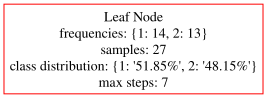

In [9]:
# select an index of a tree to visualize
dot = visualize_step_tree(rf.trees[0], all_classes)
dot.render(f'{dataset}_ts_step_tree_rf', format='pdf', cleanup=True)
dot

# Multivariate data

## data preparation for the multivariate RF (.ts)

In [16]:
# Dataset names from the Multivariate_ts DataDimensions.csv file
dataset_names = [
    "FitbitIntra_two",
    "FitbitIntra_five",
    "FitbitIntra_all",
    "FitbitIntra",
    "Fitbit",
    "ArticularyWordRecognition",
    "AtrialFibrillation",
    "BasicMotions",
    "CharacterTrajectories",
    "Cricket",
    "DuckDuckGeese",
    "EigenWorms",
    "Epilepsy",
    "EthanolConcentration",
    "ERing",
    "FaceDetection",
    "FingerMovements",
    "HandMovementDirection",
    "Handwriting",
    "Heartbeat",
    "InsectWingbeat",
    "JapaneseVowels",
    "Libras",
    "LSST",
    "MotorImagery",
    "NATOPS",
    "PenDigits",
    "PEMS-SF",
    "Phoneme",
    "RacketSports",
    "SelfRegulationSCP1",
    "SelfRegulationSCP2",
    "SpokenArabicDigits",
    "StandWalkJump",
    "UWaveGestureLibrary"
]

# Function to load the dataset based on the provided dataset name
def load_dataset(dataset_name):
    try:
        train_path = f'Multivariate_ts/{dataset_name}/{dataset_name}_TRAIN.ts'
        test_path = f'Multivariate_ts/{dataset_name}/{dataset_name}_TEST.ts'
        
        # Load training and test data using aeon's load_from_tsfile
        X_train, Y_train = load_from_tsfile(train_path)
        X_test, Y_test = load_from_tsfile(test_path)
        
        print(f"{dataset_name} training data shape: {X_train.shape}")
        print(f"{dataset_name} test data shape: {X_test.shape}")
        
        return X_train, Y_train, X_test, Y_test
    except FileNotFoundError:
        raise ValueError(f"Error: Dataset '{dataset_name}' could not be loaded. Please check the dataset name.")

# Function to check dataset validity and suggest nearest valid dataset name if not found
def check_dataset_name(dataset_name, valid_names):
    if dataset_name in valid_names:
        return dataset_name
    else:
        # Find the closest matching dataset name using fuzzy matching
        closest_match, match_score = process.extractOne(dataset_name, valid_names)
        if match_score > 60:  # Suggest if the similarity score is reasonable
            print(f"Error: Dataset '{dataset_name}' not found. Did you mean '{closest_match}'?")
        else:
            print(f"Error: Dataset '{dataset_name}' not found and no close match available.")
        return None

# Function to calculate the number of trees for a Random Forest based on dataset size
def calculate_number_of_trees(num_training_samples):
    # Constants to adjust based on experimentation
    min_trees = 200
    max_trees = 1000
    factor = 2  # Proportional factor for tree<<<<<<<<<<<<<<<<<<<<<<<<<<<
    # Calculate initial number of trees
    number_of_trees = num_training_samples * factor
    number_of_trees = max(min_trees, min(number_of_trees, max_trees))
    return number_of_trees

# General Rule for max_depth based on dataset size
def calculate_max_depth(num_training_samples):
    min_depth = 7
    max_depth_limit = 40  # Upper limit to prevent overfitting
    # Depth based on log2 of the number of samples
    depth_samples = int(math.log2(num_training_samples)) if num_training_samples > 1 else 1
    # Ensure the depth is within set bounds
    max_depth = max(min_depth, min(depth_samples, max_depth_limit))
    return max_depth

# Function to calculate min_samples_leaf based on a small percentage of the dataset size
def calculate_min_samples_leaf(num_training_samples, percentage=0.025):
    # Ensure the percentage is within a reasonable range (1% to 5%)
    percentage = max(0.01, min(percentage, 0.05))
    # Calculate min_samples_leaf
    min_samples_leaf = max(1, int(num_training_samples * percentage))
    return min_samples_leaf

# Select the dataset (input from user)
dataset = 'FitbitIntra_five'  # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<*INPUT*<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

# Check if the dataset name is valid
valid_dataset_name = check_dataset_name(dataset, dataset_names)

if valid_dataset_name:
    # Load the training and test data
    X_train_full, Y_train_full, X_test, Y_test = load_dataset(valid_dataset_name)
    
    # Print the number of unique classes in the training data
    n_classes = len(set(Y_train_full))
    print(f"Number of classes in {valid_dataset_name}: {n_classes}")

    # Split the training data into training and validation sets (15% for validation)
    X_train, X_validation, Y_train, Y_validation = train_test_split(
        X_train_full, Y_train_full, test_size=0.15, random_state=42, stratify=Y_train_full
    )
    
    num_training_samples = X_train.shape[0]
    # For multivariate data, assuming equal length, get the series length
    num_features = X_train.shape[-1]
    maxstep = math.ceil(num_features * 0.40)
    stepsize = math.ceil(num_features * 0.10)

    # Check the sizes of each set
    print(f"Training set shape: {X_train.shape}")  # (n_samples, n_channels, series_length)
    print(f"Validation set shape: {X_validation.shape}")
    print(f"Test set shape: {X_test.shape}")

    # Calculate and print 40% and 10% of the training data length, rounded up
    print(f"Length of the time series: {num_features}")
    print(f"40% of the time series length for maxstep: {maxstep}")
    print(f"10% of the time series length for stepsize: {stepsize}")

    # Calculate the recommended number of trees
    relative_n_of_trees = calculate_number_of_trees(num_training_samples)
    print("Recommended number of trees:", relative_n_of_trees)

    relative_max_depth = calculate_max_depth(num_training_samples)
    print("Recommended max_depth:", relative_max_depth)

    relative_min_samples_leaf = calculate_min_samples_leaf(num_training_samples, percentage=0.01)
    print("Recommended min_samples_leaf:", relative_min_samples_leaf)
else:
    print(f"Dataset '{dataset}' not found and no close match available.")



FitbitIntra_five training data shape: (110, 5, 1440)
FitbitIntra_five test data shape: (28, 5, 1440)
Number of classes in FitbitIntra_five: 4
Training set shape: (93, 5, 1440)
Validation set shape: (17, 5, 1440)
Test set shape: (28, 5, 1440)
Length of the time series: 1440
40% of the time series length for maxstep: 576
10% of the time series length for stepsize: 144
Recommended number of trees: 200
Recommended max_depth: 7
Recommended min_samples_leaf: 1


# * Multivariate Random Forest of ts_step_tree with catch22

Training tree 1/1
Tree 1 statistics:
  Selected dimension: 1
  Minimum steps: 576
  Median steps: 1800.0
  Maximum steps: 2736
  Standard deviation of steps: 600.20

Overall statistics across all trees:
Minimum steps across all leaf nodes: 576
Median steps across all leaf nodes: 1800.0
Maximum steps across all leaf nodes: 2736
Standard deviation of steps across all leaf nodes: 600.20
Overall Accuracy on test set: 21.43%

Classification Report:
              precision    recall  f1-score   support

          q1       0.29      0.25      0.27         8
          q2       0.00      0.00      0.00         6
          q3       0.14      0.12      0.13         8
          q4       0.21      0.50      0.30         6

    accuracy                           0.21        28
   macro avg       0.16      0.22      0.17        28
weighted avg       0.17      0.21      0.18        28

Cohen's Kappa: -0.05
Matthews Correlation Coefficient (MCC): -0.05

Per-Class Metrics:
    Precision  Recall  F1-Scor

/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packag

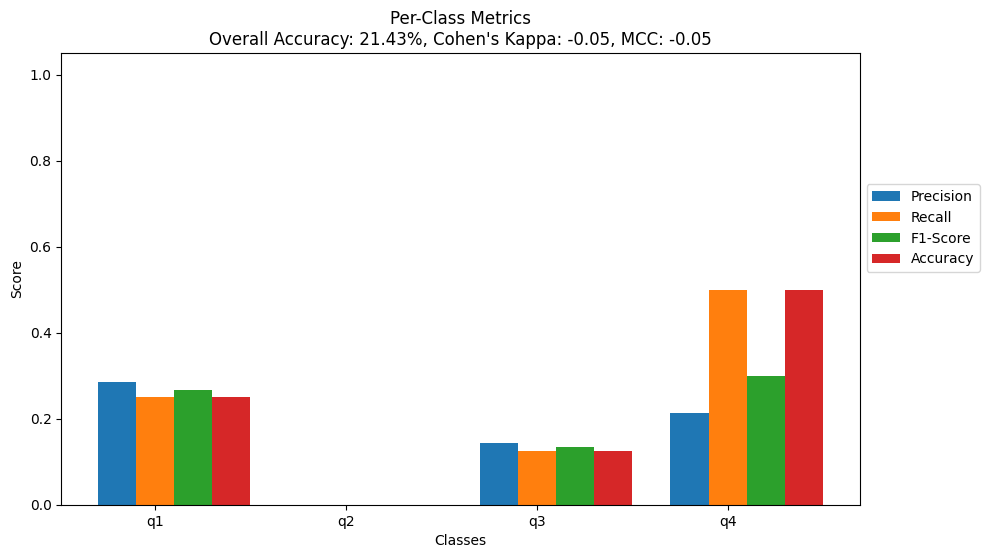

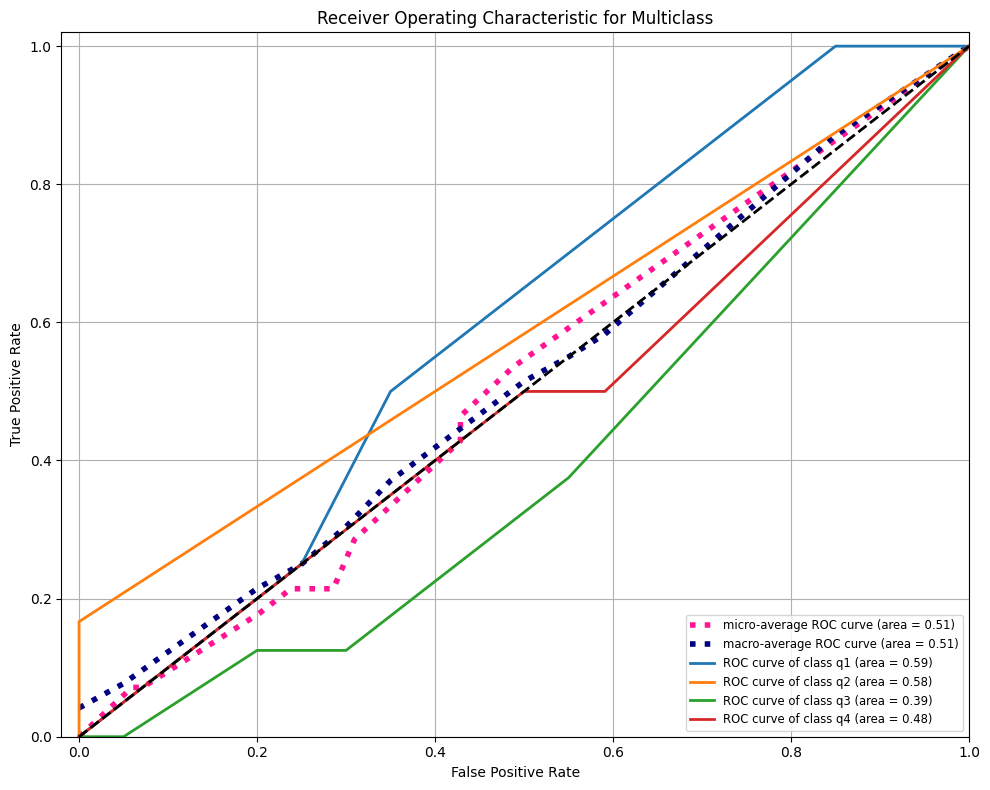

In [20]:
import warnings
# Silence deprecation warnings from sklearn
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Define the Node class with total_steps attribute
class Node:
    def __init__(
        self,
        witness,
        threshold,
        steps,
        class_distribution,
        all_classes,
        distance_metric=None,
        distance_params=None,
        use_catch22=False,  # New attribute
        total_steps=0,
    ):
        self.witness = witness
        self.threshold = threshold
        self.steps = steps
        self.total_steps = total_steps  # Store the total steps taken to reach this node
        self.distance_metric = distance_metric  # Store the selected distance metric
        self.distance_params = distance_params  # Store the selected distance parameters
        self.use_catch22 = use_catch22  # New attribute
        self.class_distribution = self.calculate_probabilities(
            class_distribution, all_classes
        )
        self.probabilities = self.class_distribution
        self.samples = sum(class_distribution.values())
        self.raw_class_distribution = {
            k: class_distribution.get(k, 0) for k in all_classes
        }
        self.TrueChild = None
        self.FalseChild = None
        # Attributes for pruning
        self.is_leaf = False
        self.validation_class_distribution = {}
        self.validation_samples = 0
        self.static_error_rate = None
        self.backed_up_error_rate = None
        self.pruned = False

    def calculate_probabilities(self, class_distribution, all_classes):
        total = sum(class_distribution.values())
        probabilities = {
            k: class_distribution.get(k, 0) / total if total > 0 else 0
            for k in all_classes
        }
        return probabilities

# Function for calculating the loss using entropy
def InformationGain(group1, group2):
    # Compute the entropy of a group
    def entropy(group):
        _, counts = np.unique(group, return_counts=True)
        probs = counts / len(group)
        return -sum(p * np.log2(p) for p in probs if p > 0)

    # Compute the information gain
    total_len = len(group1) + len(group2)
    entropy_before = entropy(np.concatenate((group1, group2)))
    entropy_after = (
        (len(group1) * entropy(group1) + len(group2) * entropy(group2)) / total_len
    )
    return entropy_before - entropy_after

# Function to calculate estimated error rates and perform pruning
def post_prune_tree(node, all_classes):
    if node.is_leaf:
        # Calculate estimated error rate for leaf node
        if node.validation_class_distribution:
            majority_class_count = node.validation_class_distribution.get(
                max(
                    node.validation_class_distribution,
                    key=node.validation_class_distribution.get,
                    default=None,
                ),
                0,
            )
        else:
            majority_class_count = 0
        total = node.validation_samples
        if total > 0:
            node.static_error_rate = 1 - (majority_class_count / total)
        else:
            node.static_error_rate = 0  # No validation samples reached this node
        node.backed_up_error_rate = node.static_error_rate
    else:
        # Recursively prune child nodes
        post_prune_tree(node.TrueChild, all_classes)
        post_prune_tree(node.FalseChild, all_classes)
        # Calculate static error rate if we prune this node
        if node.validation_class_distribution:
            majority_class_count = node.validation_class_distribution.get(
                max(
                    node.validation_class_distribution,
                    key=node.validation_class_distribution.get,
                    default=None,
                ),
                0,
            )
        else:
            majority_class_count = 0
        total = node.validation_samples
        if total > 0:
            node.static_error_rate = 1 - (majority_class_count / total)
        else:
            node.static_error_rate = 0  # No validation samples reached this node
        # Calculate backed-up error rate from children
        true_child = node.TrueChild
        false_child = node.FalseChild
        total_children = true_child.validation_samples + false_child.validation_samples
        if total_children > 0:
            node.backed_up_error_rate = (
                (true_child.validation_samples / total_children)
                * true_child.backed_up_error_rate
                + (false_child.validation_samples / total_children)
                * false_child.backed_up_error_rate
            )
        else:
            node.backed_up_error_rate = 0  # No validation samples in children
        # Decide whether to prune
        if node.static_error_rate <= node.backed_up_error_rate:
            # Prune the subtree
            node.TrueChild = None
            node.FalseChild = None
            node.is_leaf = True
            node.pruned = True
            node.backed_up_error_rate = node.static_error_rate
        else:
            node.pruned = False
            node.backed_up_error_rate = node.backed_up_error_rate

# Function for catch22
def to_catch(timeseries_set):
    catch22_list = []
    for ts in timeseries_set:
        features = catch22_all(ts)['values']
        if np.isnan(features).any():
            print("NaNs detected in catch22 features.")
            features = np.nan_to_num(features)
        catch22_list.append(features)
    return np.array(catch22_list)

# Main training function for the tree model
def TS_Step_Tree_Train(
    X,
    Y,
    X_val,
    Y_val,
    maxstep,
    stepsize,
    maxd,
    mins,
    all_classes,
    distance_functions,
    allow_step_reuse=True,
    post_pruning=True,
    total_steps=0,
):
    def frequencies(Y):
        unique, counts = np.unique(Y, return_counts=True)
        return dict(zip(unique, counts))

    if (
        len(set(Y)) == 1
        or maxd == 0
        or len(X) < mins
        or min(len(ts) for ts in X) < stepsize
    ):
        node = Node(None, None, None, frequencies(Y), all_classes, total_steps=total_steps)
        node.is_leaf = True
        # Assign validation data to the leaf node
        node.validation_class_distribution = frequencies(Y_val)
        node.validation_samples = len(Y_val)
    else:
        real_maxstep = min(maxstep, min(len(ts) for ts in X))
        i = 1
        bestIg = 0
        best_witness = None
        best_threshold = None
        best_steps = None
        best_distance_metric = None
        best_distance_params = None
        best_use_catch22 = False  # New variable
        while i * stepsize <= real_maxstep:
            X_subset = np.ascontiguousarray([ts[: i * stepsize] for ts in X])
            # Find the best witness and split using different distance functions
            Ig, witness, threshold, distance_metric, distance_params, use_catch22 = Find_Witness(
                X_subset, Y, distance_functions
            )
            if bestIg < Ig:
                bestIg = Ig
                best_witness = witness
                best_threshold = threshold
                best_steps = i * stepsize
                best_distance_metric = distance_metric
                best_distance_params = distance_params
                best_use_catch22 = use_catch22  # Update variable
            i += 1

        if bestIg == 0:
            node = Node(None, None, None, frequencies(Y), all_classes, total_steps=total_steps)
            node.is_leaf = True
            # Assign validation data to the leaf node
            node.validation_class_distribution = frequencies(Y_val)
            node.validation_samples = len(Y_val)
        else:
            node = Node(
                best_witness,
                best_threshold,
                best_steps,
                frequencies(Y),
                all_classes,
                distance_metric=best_distance_metric,
                distance_params=best_distance_params,
                use_catch22=best_use_catch22,  # Pass variable
                total_steps=total_steps + best_steps,
            )
            # Split the training data
            TrueIndexes = []
            for idx in range(len(X)):
                try:
                    if best_use_catch22:
                        # Compute catch22 features for the sliced time series
                        ts = X[idx][:best_steps]
                        catch22_x = to_catch([ts])[0]
                        # Compute distance using specified metric
                        distance = pairwise_distances(
                            [node.witness], [catch22_x],
                            metric=best_distance_metric,
                            **best_distance_params
                        )[0][0]
                    else:
                        distance = aeon_distance(
                            np.ascontiguousarray(best_witness),
                            np.ascontiguousarray(X[idx][: best_steps]),
                            metric=best_distance_metric,
                            **best_distance_params,
                        )
                except Exception as e:
                    print(f"Error computing distance for index {idx}: {e}")
                    continue

                if distance <= best_threshold:
                    TrueIndexes.append(idx)

            FalseIndexes = [idx for idx in range(len(X)) if idx not in TrueIndexes]

            # Split the validation data
            TrueValIndexes = []
            for idx in range(len(X_val)):
                try:
                    if best_use_catch22:
                        ts = X_val[idx][:best_steps]
                        catch22_x = to_catch([ts])[0]
                        distance = pairwise_distances(
                            [node.witness], [catch22_x],
                            metric=best_distance_metric,
                            **best_distance_params
                        )[0][0]
                    else:
                        distance = aeon_distance(
                            np.ascontiguousarray(best_witness),
                            np.ascontiguousarray(X_val[idx][: best_steps]),
                            metric=best_distance_metric,
                            **best_distance_params,
                        )
                except Exception as e:
                    print(f"Error computing validation distance for index {idx}: {e}")
                    continue

                if distance <= best_threshold:
                    TrueValIndexes.append(idx)

            FalseValIndexes = [idx for idx in range(len(X_val)) if idx not in TrueValIndexes]

            # Recursive calls for children
            node.TrueChild = TS_Step_Tree_Train(
                [X[idx][best_steps:] for idx in TrueIndexes],
                Y[TrueIndexes],
                [X_val[idx][best_steps:] for idx in TrueValIndexes],
                Y_val[TrueValIndexes],
                maxstep,
                stepsize,
                maxd - 1,
                mins,
                all_classes,
                distance_functions,
                allow_step_reuse,
                post_pruning=False,
                total_steps=node.total_steps,
            )
            if allow_step_reuse:
                node.FalseChild = TS_Step_Tree_Train(
                    [X[idx][:] for idx in FalseIndexes],
                    Y[FalseIndexes],
                    [X_val[idx][:] for idx in FalseValIndexes],
                    Y_val[FalseValIndexes],
                    maxstep,
                    stepsize,
                    maxd - 1,
                    mins,
                    all_classes,
                    distance_functions,
                    allow_step_reuse,
                    post_pruning=False,
                    total_steps=node.total_steps,
                )
            else:
                node.FalseChild = TS_Step_Tree_Train(
                    [X[idx][best_steps + 1 :] for idx in FalseIndexes],
                    Y[FalseIndexes],
                    [X_val[idx][best_steps + 1 :] for idx in FalseValIndexes],
                    Y_val[FalseValIndexes],
                    maxstep,
                    stepsize,
                    maxd - 1,
                    mins,
                    all_classes,
                    distance_functions,
                    allow_step_reuse,
                    post_pruning=False,
                    total_steps=node.total_steps,
                )
            # Assign validation data to the node
            node.validation_class_distribution = frequencies(Y_val)
            node.validation_samples = len(Y_val)

    # Perform post-pruning if enabled
    if post_pruning:
        post_prune_tree(node, all_classes)

    return node

def Find_Witness(X_subset, Y, distance_functions):
    max_loss = 0
    best_witness = None
    best_threshold = None
    best_distance_metric = None
    best_distance_params = None
    best_use_catch22 = False  # New variable

    for dist_func in distance_functions:
        metric = dist_func['metric']
        param_grid = dist_func.get('params', [{}])  # Default to [{}] if no params
        use_catch22 = dist_func.get('use_catch22', False)  # New parameter

        for params in param_grid:
            try:
                if use_catch22:
                    # Compute catch22 features
                    catch22_features = to_catch(X_subset)
                    # Check for NaNs
                    if np.isnan(catch22_features).any():
                        print("NaNs detected in catch22 features.")
                        continue
                    # Compute distance matrix using the specified metric
                    DM = pairwise_distances(catch22_features, metric=metric, **params)
                else:
                    # Compute distance matrix using the specified metric on raw time series
                    DM = aeon_pairwise_distance(X_subset, metric=metric, **params)
            except Exception as e:
                print(f"Error computing distances with metric {metric}, params {params}, use_catch22 {use_catch22}: {e}")
                continue

            for i in range(len(X_subset)):
                value, threshold = best_cut(i, Y, DM, InformationGain)
                if value > max_loss:
                    max_loss = value
                    if use_catch22:
                        best_witness = catch22_features[i]
                    else:
                        best_witness = X_subset[i]
                    best_threshold = threshold
                    best_distance_metric = metric
                    best_distance_params = params
                    best_use_catch22 = use_catch22  # Update variable

    return max_loss, best_witness, best_threshold, best_distance_metric, best_distance_params, best_use_catch22

def best_cut(idx, Y, DM, Loss):
    pairs = [(DM[j, idx], Y[j]) for j in range(len(Y))]
    pairs.sort(key=lambda x: x[0])
    if len(pairs) < 2:
        return 0, 0  # Cannot split
    loss_values = [
        Loss(
            np.array([p[1] for p in pairs[:j]]),
            np.array([p[1] for p in pairs[j:]]),
        )
        for j in range(1, len(Y))
    ]
    j = np.argmax(loss_values)
    threshold = (pairs[j][0] + pairs[j - 1][0]) / 2

    return loss_values[j], threshold

def predict(node, x):
    if node.is_leaf:
        return node.probabilities
    distance_metric = node.distance_metric
    distance_params = node.distance_params if node.distance_params else {}
    use_catch22 = node.use_catch22  # Retrieve attribute

    if len(x) == 0 or len(node.witness) == 0:
        return node.probabilities

    if use_catch22:
        # Compute catch22 features
        ts = x[:node.steps]
        catch22_x = to_catch([ts])[0]
        # Compute distance
        distance = pairwise_distances(
            [node.witness], [catch22_x],
            metric=distance_metric,
            **distance_params
        )[0][0]
        next_x = x  # Since we've used the whole time series for catch22, no need to slice
    else:
        # Use the specified distance metric on time series
        distance = aeon_distance(
            np.ascontiguousarray(node.witness),
            np.ascontiguousarray(x[: node.steps]),
            metric=distance_metric,
            **distance_params,
        )
        next_x = x[node.steps:] if len(x) > node.steps else np.array([])

    if distance <= node.threshold:
        if node.TrueChild is not None:
            return predict(node.TrueChild, next_x)
        else:
            return node.probabilities
    else:
        if node.FalseChild is not None:
            return predict(node.FalseChild, next_x)
        else:
            return node.probabilities

# New function to collect steps from leaf nodes
def collect_leaf_steps(node, steps_list):
    if node.is_leaf:
        if node.total_steps is not None:
            steps_list.append(node.total_steps)
    else:
        if node.TrueChild:
            collect_leaf_steps(node.TrueChild, steps_list)
        if node.FalseChild:
            collect_leaf_steps(node.FalseChild, steps_list)

# Implement the Random Forest
class RandomForest:
    def __init__(
        self,
        n_trees,
        maxstep,
        stepsize,
        maxd,
        mins,
        distance_functions,
        allow_step_reuse=True,
        post_pruning=True,
    ):
        self.n_trees = n_trees
        self.maxstep = maxstep
        self.stepsize = stepsize
        self.maxd = maxd
        self.mins = mins
        self.allow_step_reuse = allow_step_reuse
        self.post_pruning = post_pruning
        self.distance_functions = distance_functions
        self.trees = []
        self.selected_dimensions = []  # To store the selected dimension for each tree
        self.all_classes = None
        self.all_steps_list = []  # To store steps from all leaf nodes across all trees

    def fit(self, X, Y):
        self.all_classes = np.unique(Y)
        n_samples = len(X)
        n_dimensions = X.shape[1]  # Number of dimensions/channels

        # Build each tree
        for i in range(self.n_trees):
            print(f"Training tree {i + 1}/{self.n_trees}")
            # Randomly select a dimension
            selected_dim = np.random.randint(0, n_dimensions)
            self.selected_dimensions.append(selected_dim)
            
            # Extract data for the selected dimension
            X_dim = X[:, selected_dim, :]
            
            # Bootstrap sampling
            indices = np.random.choice(n_samples, n_samples, replace=True)
            oob_indices = [idx for idx in range(n_samples) if idx not in indices]
            X_bootstrap = [X_dim[idx] for idx in indices]
            Y_bootstrap = Y[indices]
            X_oob = [X_dim[idx] for idx in oob_indices]
            Y_oob = Y[oob_indices]
            
            # Train the tree
            tree = TS_Step_Tree_Train(
                X_bootstrap,
                Y_bootstrap,
                X_oob,
                Y_oob,
                self.maxstep,
                self.stepsize,
                self.maxd,
                self.mins,
                self.all_classes,
                self.distance_functions,
                self.allow_step_reuse,
                self.post_pruning,
            )
            self.trees.append(tree)
            # Collect steps from leaf nodes of this tree
            tree_steps_list = []
            collect_leaf_steps(tree, tree_steps_list)
            self.all_steps_list.extend(tree_steps_list)
            # Calculate statistics for this tree
            if tree_steps_list:
                min_steps_tree = min(tree_steps_list)
                max_steps_tree = max(tree_steps_list)
                median_steps_tree = np.median(tree_steps_list)
                std_steps_tree = np.std(tree_steps_list)
            else:
                min_steps_tree = max_steps_tree = median_steps_tree = std_steps_tree = 0
            print(f"Tree {i + 1} statistics:")
            print(f"  Selected dimension: {selected_dim}")
            print(f"  Minimum steps: {min_steps_tree}")
            print(f"  Median steps: {median_steps_tree}")
            print(f"  Maximum steps: {max_steps_tree}")
            print(f"  Standard deviation of steps: {std_steps_tree:.2f}")
        
        # Calculate overall statistics across all trees
        if self.all_steps_list:
            min_steps = min(self.all_steps_list)
            max_steps = max(self.all_steps_list)
            median_steps = np.median(self.all_steps_list)
            std_steps = np.std(self.all_steps_list)
        else:
            min_steps = max_steps = median_steps = std_steps = 0

        print("\nOverall statistics across all trees:")
        print(f"Minimum steps across all leaf nodes: {min_steps}")
        print(f"Median steps across all leaf nodes: {median_steps}")
        print(f"Maximum steps across all leaf nodes: {max_steps}")
        print(f"Standard deviation of steps across all leaf nodes: {std_steps:.2f}")

    def predict_proba(self, x):
        # Aggregate probabilities from all trees
        probabilities_list = []
        for tree, selected_dim in zip(self.trees, self.selected_dimensions):
            x_dim = x[selected_dim]  # Extract the dimension used by the tree
            probabilities = predict(tree, x_dim)
            probabilities_list.append(probabilities)
        # Average the probabilities
        avg_probabilities = {}
        for cls in self.all_classes:
            avg_probabilities[cls] = np.mean(
                [prob.get(cls, 0) for prob in probabilities_list]
            )
        return avg_probabilities

    def predict(self, x):
        avg_probabilities = self.predict_proba(x)
        predicted_class = max(avg_probabilities, key=avg_probabilities.get)
        return predicted_class

    def evaluate(self, X_test, Y_test, class_names):
        y_true, y_pred = [], []
        probabilities_list = []  # For ROC curves
        for x, y_t in zip(X_test, Y_test):
            prob = self.predict_proba(x)
            y_p = max(prob, key=prob.get)
            y_true.append(y_t)
            y_pred.append(y_p)
            # Ensure the probabilities are in the same order as 'class_names'
            probabilities = [prob.get(cls, 0) for cls in class_names]
            probabilities_list.append(probabilities)
        # Compute overall accuracy
        correct = sum(1 for y_t, y_p in zip(y_true, y_pred) if y_t == y_p)
        total = len(Y_test)
        accuracy = correct / total
        print(f"Overall Accuracy on test set: {accuracy * 100:.2f}%")
        # Generate classification report
        report = classification_report(
            y_true,
            y_pred,
            labels=class_names,
            output_dict=True,
            zero_division='warn',
        )
        print("\nClassification Report:")
        print(
            classification_report(
                y_true, y_pred, labels=class_names, zero_division='warn'
            )
        )
        # Calculate Cohen's Kappa
        kappa = cohen_kappa_score(y_true, y_pred)
        print(f"Cohen's Kappa: {kappa:.2f}")
        # Calculate Matthews Correlation Coefficient (MCC)
        mcc = matthews_corrcoef(y_true, y_pred)
        print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")
        # Calculate per-class accuracy
        cm = confusion_matrix(y_true, y_pred, labels=class_names)
        per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
        # Prepare data for visualization
        metrics_df = pd.DataFrame(index=class_names)
        metrics_df['Precision'] = [
            report[str(cls)]['precision'] for cls in class_names
        ]
        metrics_df['Recall'] = [report[str(cls)]['recall'] for cls in class_names]
        metrics_df['F1-Score'] = [
            report[str(cls)]['f1-score'] for cls in class_names
        ]
        metrics_df['Accuracy'] = per_class_accuracy
        # Kappa and MCC are overall metrics; replicate them for each class for visualization
        metrics_df["Cohen's Kappa"] = kappa
        metrics_df['MCC'] = mcc
        # Display the DataFrame
        print("\nPer-Class Metrics:")
        print(metrics_df)
        # Plot the metrics
        self.plot_metrics(metrics_df, class_names, accuracy, kappa, mcc)
        # Compute and plot ROC curves
        self.plot_roc_curves(y_true, probabilities_list, class_names)

    def plot_metrics(self, metrics_df, class_names, accuracy, kappa, mcc):
        # Plotting code remains unchanged
        metrics = ['Precision', 'Recall', 'F1-Score', 'Accuracy']
        plt.figure(figsize=(10, 6))
        x = np.arange(len(class_names))
        width = 0.2
        for i, metric in enumerate(metrics):
            plt.bar(
                x + i * width,
                metrics_df[metric],
                width=width,
                label=metric,
                align='center',
            )
        plt.xlabel('Classes')
        plt.ylabel('Score')
        plt.title(
            'Per-Class Metrics\n'
            f'Overall Accuracy: {accuracy * 100:.2f}%, '
            f"Cohen's Kappa: {kappa:.2f}, MCC: {mcc:.2f}"
        )
        plt.xticks(x + width, class_names)
        plt.ylim(0, 1.05)
        plt.legend(loc='lower left', bbox_to_anchor=(1, 0.5))
        plt.tight_layout()
        plt.subplots_adjust(top=0.85)  # Add padding to the top
        plt.savefig(f'{dataset}_RF_metrics.pdf')
        plt.show()

    def plot_roc_curves(self, y_true, probabilities_list, class_names):
        # ROC curve plotting code remains unchanged
        n_classes = len(class_names)
        if n_classes == 2:
            y_true_binary = label_binarize(y_true, classes=class_names)[:, 0]
            y_scores = [prob[1] for prob in probabilities_list]
            fpr, tpr, _ = roc_curve(y_true_binary, y_scores)
            roc_auc = auc(fpr, tpr)
            plt.figure(figsize=(8, 6))
            plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
            plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
            plt.xlim([0.0, 1.0])
            plt.ylim([0.0, 1.05])
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title('Receiver Operating Characteristic')
            plt.legend(loc='lower right')
            plt.savefig(f'{dataset}_RF_roc.pdf')
            plt.show()
        else:
            # Multiclass ROC curves
            y_true_binary = label_binarize(y_true, classes=class_names)
            probabilities_array = np.array(probabilities_list)
            # Compute ROC curve and ROC area for each class
            fpr = dict()
            tpr = dict()
            roc_auc = dict()
            for i in range(n_classes):
                fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], probabilities_array[:, i])
                roc_auc[i] = auc(fpr[i], tpr[i])
            # Compute micro-average ROC curve and ROC area
            fpr["micro"], tpr["micro"], _ = roc_curve(
                y_true_binary.ravel(), probabilities_array.ravel()
            )
            roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
            # Compute macro-average ROC curve and ROC area
            all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
            mean_tpr = np.zeros_like(all_fpr)
            for i in range(n_classes):
                mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
            mean_tpr /= n_classes
            fpr["macro"] = all_fpr
            tpr["macro"] = mean_tpr
            roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])
            # Plot all ROC curves
            plt.figure(figsize=(10, 8))
            plt.plot(
                fpr["micro"],
                tpr["micro"],
                label='micro-average ROC curve (area = {0:0.2f})'.format(roc_auc["micro"]),
                color='deeppink',
                linestyle=':',
                linewidth=4,
            )
            plt.plot(
                fpr["macro"],
                tpr["macro"],
                label='macro-average ROC curve (area = {0:0.2f})'.format(roc_auc["macro"]),
                color='navy',
                linestyle=':',
                linewidth=4,
            )
            colors = plt.cm.get_cmap('tab10').colors
            for i, color in zip(range(n_classes), colors):
                plt.plot(
                    fpr[i],
                    tpr[i],
                    color=color,
                    lw=2,
                    label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]),
                )
            plt.plot([0, 1], [0, 1], 'k--', lw=2)
            plt.xlim([-0.02, 1.0])
            plt.ylim([0.0, 1.02])
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title('Receiver Operating Characteristic for Multiclass')
            plt.legend(loc='lower right', fontsize='small')
            plt.grid(True)
            plt.tight_layout()
            plt.savefig(f'{dataset}_RF_roc.pdf')
            plt.show()

# Define the distance functions and parameter grids to test

distance_functions = [
    

    {'metric': 'dtw', 'params': [{}], 'use_catch22': False},
    {'metric': 'ddtw', 'params': [{'window': None}, {'window': 0}, {'window': 0.25}, {'window': 0.5}, {'window': 0.75}, {'window': 1.0}, {'itakura_max_slope': None}, {'itakura_max_slope': 0.5}, {'itakura_max_slope': 1.0}]},
]

'''

distance_functions = [
    {'metric': 'euclidean', 'params': [{}], 'use_catch22': False},
    {'metric': 'euclidean', 'params': [{}], 'use_catch22': True},
    {'metric': 'dtw', 'params': [{}], 'use_catch22': False},
    {'metric': 'euclidean', 'params': [{}], 'use_catch22': True},
    {'metric': 'euclidean', 'params': [{}], 'use_catch22': False},
    {'metric': 'manhattan', 'params': [{}], 'use_catch22': False},
    {'metric': 'squared', 'params': [{}]},
    {'metric': 'minkowski', 'params': [{'p': 1.0}, {'p': 3.0}]},
    {'metric': 'dtw', 'params': [{'window': None}, {'window': 0}, {'window': 0.25}, {'window': 0.5}, {'window': 0.75}, {'window': 1.0}, {'itakura_max_slope': None}, {'itakura_max_slope': 0.5}, {'itakura_max_slope': 1.0}]},
    {'metric': 'ddtw', 'params': [{'window': None}, {'window': 0}, {'window': 0.25}, {'window': 0.5}, {'window': 0.75}, {'window': 1.0}, {'itakura_max_slope': None}, {'itakura_max_slope': 0.5}, {'itakura_max_slope': 1.0}]},
    {'metric': 'wdtw', 'params': [{'g': 0.05}, {'g': 0.1}, {'g': 0.25}, {'itakura_max_slope': None}, {'itakura_max_slope': 0.5}, {'itakura_max_slope': 1.0}]}, #or sakoe_chiba_radius from none, 0 to 1.0
    {'metric': 'wddtw', 'params': [{'g': 0.05}, {'g': 0.1}, {'g': 0.25}, {'itakura_max_slope': None}, {'itakura_max_slope': 0.5}, {'itakura_max_slope': 1.0}]},
    {'metric': 'lcss', 'params': [{'epsilon': 0.5}, {'epsilon': 1.0}, {'epsilon': 1.75}, {'epsilon': 3}]},
    {'metric': 'edr', 'params': [{'epsilon': 0.5}, {'epsilon': 1.0}, {'epsilon': 1.75}, {'epsilon': 3}]},
    {'metric': 'erp', 'params': [{'g': 0.0}, {'g': 0.5}, {'g': 1.0}]},
    {'metric': 'msm', 'params': [{'c': 0.01}, {'c': 0.1}, {'c': 1.0}, {'independent': True}, {'independent': False}]},
    {'metric': 'twe', 'params': [{'nu': 0.001, 'lambda': 1.0}, {'nu': 0.001, 'lambda': 1.5}, {'nu': 0.001, 'lambda': 2.0}]},
    {'metric': 'adtw', 'params': [{'warp_penalty': 0.5}, {'warp_penalty': 1.0}, {'warp_penalty': 2.0}]},
    {'metric': 'sbd', 'params': [{'standardize': True}, {'standardize': False}]},
    {'metric': 'shape_dtw', 'params': [{'reach': 10}, {'reach': 30}, {'reach': 50},
    ]}
]
'''

# Initialize the Random Forest
rf = RandomForest(
    n_trees= 1, #relative_n_of_trees,
    maxstep=maxstep,
    stepsize=stepsize,
    maxd=relative_max_depth,
    mins=1, #relative_min_samples_leaf,
    distance_functions=distance_functions,
    allow_step_reuse=True,  # Set to False to exclude used steps in child nodes
    post_pruning=True,
)

# Fit the Random Forest
rf.fit(X_train_full, Y_train_full)

# Define class names (labels)
class_names = sorted(np.unique(Y_train_full))

# Evaluate the Random Forest on the test set
rf.evaluate(X_test, Y_test, class_names)

## Visualize a tree in the Multivariate Random Forest

Selected Dimension for Tree of index 0 is 4
Tree visualization saved as 'FitbitIntra_five_ts_step_tree_rf_tree_0_dim_4.pdf'


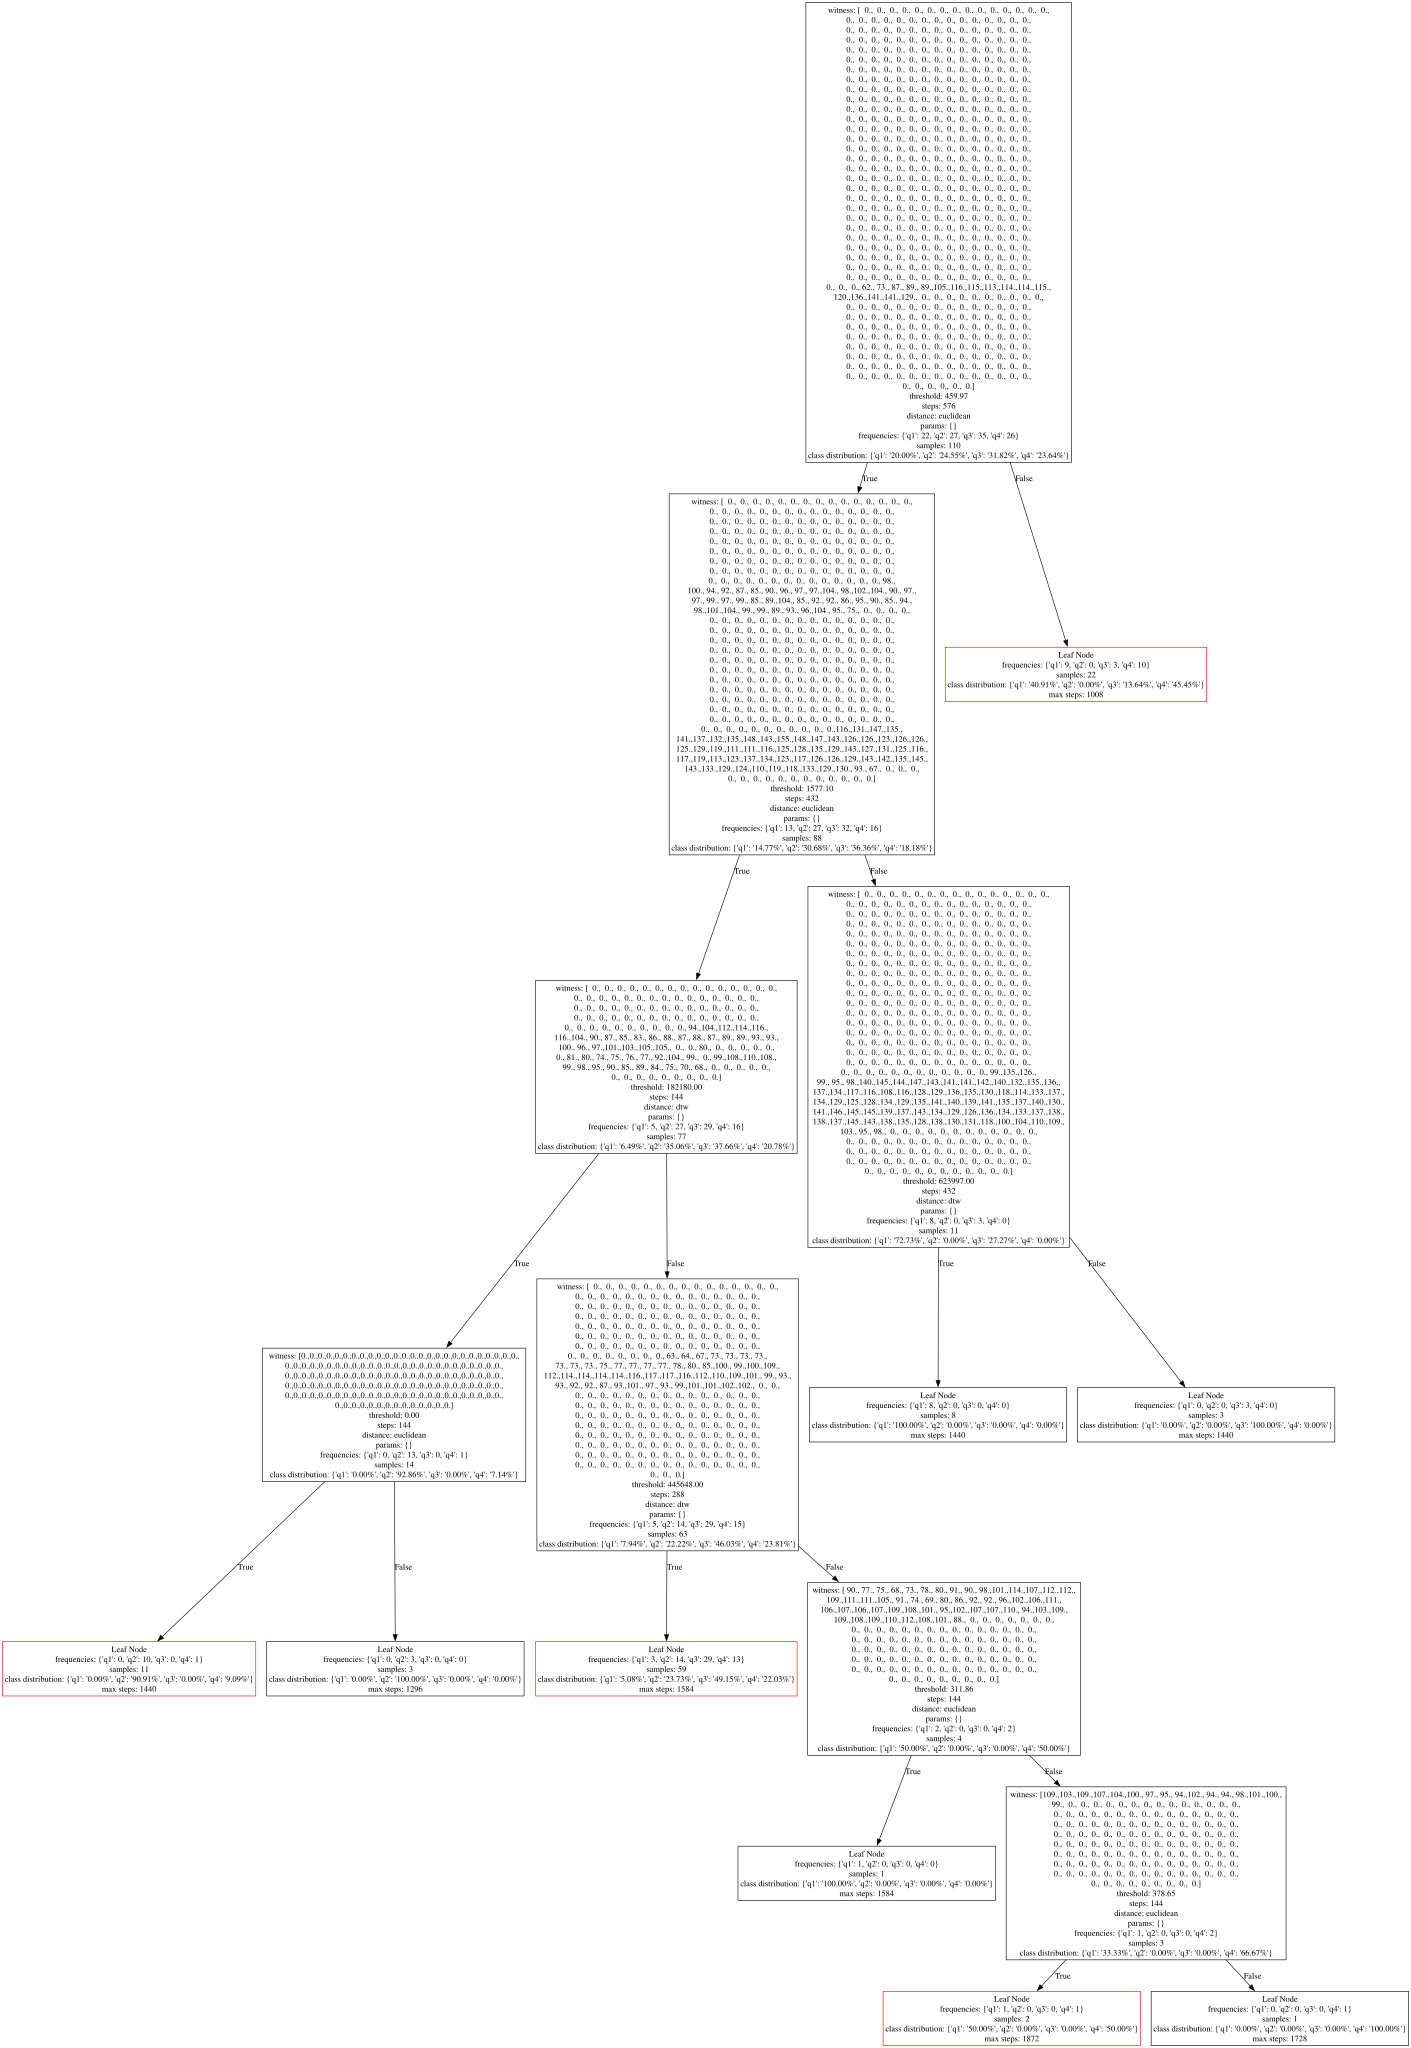

In [18]:
# Visualize the tree using graphviz, highlighting pruned nodes in red and showing additional new statistics
def visualize_step_tree(node, all_classes, dot=None, root_steps=None):
    if dot is None:
        dot = graphviz.Digraph()
        root_steps = node.steps if node.steps is not None else 0

    steps_list = []
    collect_leaf_steps(node, steps_list)

    # Calculate the overall max steps
    overall_max_steps = max(steps_list) if steps_list else root_steps

    if node.is_leaf:
        if not node.class_distribution:
            node_label = 'Leaf Node\nNo Data'
        else:
            total = sum(node.raw_class_distribution.values())
            class_distribution = {k: (node.raw_class_distribution.get(k, 0) / total) * 100 for k in all_classes}
            max_steps = node.total_steps
            node_label = 'Leaf Node\nfrequencies: {}\nsamples: {}\nclass distribution: {}\nmax steps: {}'.format(
                node.raw_class_distribution,
                node.samples,
                {k: f'{v:.2f}%' for k, v in class_distribution.items()},
                max_steps
            )
    else:
        total = sum(node.raw_class_distribution.values())
        class_distribution = {k: (node.raw_class_distribution.get(k, 0) / total) * 100 for k in all_classes}
        # Convert witness to string with limited length to avoid clutter
        witness_str = np.array2string(node.witness, precision=2, separator=',', suppress_small=True, max_line_width=80)
        node_label = 'witness: {}\nthreshold: {:.2f}\nsteps: {}\ndistance: {}\nparams: {}\nfrequencies: {}\nsamples: {}\nclass distribution: {}'.format(
            witness_str,
            node.threshold,
            node.steps,
            node.distance_metric,
            node.distance_params,
            node.raw_class_distribution,
            node.samples,
            {k: f'{v:.2f}%' for k, v in class_distribution.items()}
        )
        node_label += f'\ncatch22'  if node.use_catch22 else ''


    # Highlight pruned nodes in red
    if node.pruned:
        dot.node(str(id(node)), label=node_label, color='red', shape='box')
    else:
        dot.node(str(id(node)), label=node_label, shape='box')

    if not node.is_leaf:
        if node.TrueChild:
            dot.edge(str(id(node)), str(id(node.TrueChild)), label='True')
            visualize_step_tree(node.TrueChild, all_classes, dot, root_steps)
        if node.FalseChild:
            dot.edge(str(id(node)), str(id(node.FalseChild)), label='False')
            visualize_step_tree(node.FalseChild, all_classes, dot, root_steps)
    return dot

# Select the tree index you want to visualize (0-based indexing)
tree_index = 0  # Change here <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

# Check if the tree_index is within the range of available trees
if tree_index < len(rf.trees):
    # Retrieve the tree to visualize
    tree_to_visualize = rf.trees[tree_index]
    
    # Retrieve the list of all class labels
    all_classes = rf.all_classes
    
    # Retrieve the selected dimension for this tree
    try:
        selected_dim = rf.selected_dimensions[tree_index]
        print(f"Selected Dimension for Tree of index {tree_index} is {selected_dim}")
    except AttributeError:
        print("Error: 'selected_dimensions' attribute not found in the Random Forest model.")
        print("Ensure that 'selected_dimensions' is properly initialized and populated during training.")
        selected_dim = None
    except IndexError:
        print(f"Error: Tree index {tree_index} is out of range.")
        selected_dim = None
    
    if selected_dim is not None:
        # existing visualize_step_tree function
        dot = visualize_step_tree(tree_to_visualize, all_classes)
        
        # Render the tree to a PDF file
        pdf_filename = f'{dataset}_ts_step_tree_rf_tree_{tree_index}_dim_{selected_dim}'
        dot.render(pdf_filename, format='pdf', cleanup=True)
        print(f"Tree visualization saved as '{pdf_filename}.pdf'")
        
        # Display the tree inline for Jupyter notebook
        display(dot)
    else:
        print("Cannot visualize the tree due to the above error.")
else:
    print(f"You asked to visualize the tree number {tree_index + 1} out of {len(rf.trees)} available trees! remember it is 0-based indexing. :)")


## Testing and Choosing the Best Class Imbalance Technique

In [43]:
#!pip install -q -U imbalanced-learn
import pandas as pd
import numpy as np
import datetime
import math
import os
import warnings
import imblearn as imblearn
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.combine import SMOTEENN, SMOTETomek
from sklearn.metrics import classification_report, cohen_kappa_score, matthews_corrcoef, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from aeon.datasets import load_from_tsfile
from fuzzywuzzy import process
from sklearn.metrics import confusion_matrix, roc_curve, auc

#  all custom imports must be included, like aeon_distance, catch22_all, and the RandomForest class from your snippet, are included. import aeon_distance, catch22_all, RandomForest, etc.

# -------------------------------------------------------------------------
# Define Class Imbalance Techniques
# -------------------------------------------------------------------------

class ComboSampling:
    def fit_resample(self, X, y):
        X_res, y_res = SMOTE().fit_resample(X, y)
        X_res, y_res = RandomUnderSampler().fit_resample(X_res, y_res)
        return X_res, y_res

# We'll define a helper function to reshape data after resampling since we deal with time series arrays.
def reshape_after_resample(X, y, original_shape):
    # original shape: (n_samples, n_channels, series_length)
    # After resampling, we get X as 2D array. We need to reshape back if possible.
    # However, since we're using distances that assume a certain structure, ensure that
    # X is in the same shape. In many cases, SMOTE etc. expect 2D arrays. We might flatten.
    # A simple approach: reshape (n_samples, n_channels*series_length)
    # and after resampling reshape back if possible.
    n_channels = original_shape[1]
    series_length = original_shape[2]
    # Before resampling, we can flatten X_train to (n_samples, n_channels*series_length)
    # Let's define a helper to flatten and unflatten:
    return X.reshape(-1, n_channels, series_length), y

def flatten_for_resample(X):
    # Flatten from (n_samples, n_channels, series_length) to (n_samples, n_channels*series_length)
    n_samples, n_channels, series_length = X.shape
    return X.reshape(n_samples, n_channels*series_length)

# Techniques dictionary:
# key: technique name, value: (sampler_instance or None, class_weights or None)
# If sampler_instance is not None, we will resample. If class_weights is not None, apply inside training if supported.
techniques = {
    "Baseline": (None, None),
    "Random_Undersampling": (RandomUnderSampler(), None),
    "Random_Oversampling": (RandomOverSampler(), None),
    "SMOTE": (SMOTE(), None),
    "ADASYN": (ADASYN(), None),
    "SMOTEENN": (SMOTEENN(), None),
    "SMOTETomek": (SMOTETomek(), None),
    "Combo_Sampling": (ComboSampling(), None),
}

# Class weighting example:
# If you want to try class weighting, you'd calculate something like:
class_counts = pd.Series(Y_train).value_counts()
total_count = class_counts.sum()
class_weights = {cls: total_count/class_counts[cls] for cls in class_counts.index}
# Add it as a separate technique (only if ts_step_tree supports it)
# techniques["Class_Weighting"] = (None, class_weights)  # Uncomment if supported

# -------------------------------------------------------------------------
# Evaluate Each Technique
# -------------------------------------------------------------------------
results = {}

for technique_name, (sampler, cw) in techniques.items():
    print(f"\n=== Applying technique: {technique_name} ===")
    # Copy original training data to avoid contamination
    X_train_current = X_train.copy()
    Y_train_current = Y_train.copy()

    # Flatten if we are going to resample
    if sampler is not None:
        X_train_flat = flatten_for_resample(X_train_current)
        X_train_res, Y_train_res = sampler.fit_resample(X_train_flat, Y_train_current)
        # Reshape back to original shape
        X_train_current, Y_train_current = reshape_after_resample(X_train_res, Y_train_res, X_train_current.shape)
        print("New class distribution:", pd.Series(Y_train_current).value_counts())
    else:
        print("No resampling applied. Using original class distribution:", pd.Series(Y_train_current).value_counts())

    # Train a new RandomForest for each technique
    rf = RandomForest(
        n_trees=10,
        maxstep=maxstep,
        stepsize=stepsize,
        maxd=relative_max_depth,
        mins=1, # you can adjust min_samples_leaf if desired
        distance_functions=[
            {'metric': 'euclidean', 'params': [{}], 'use_catch22': True},
            {'metric': 'euclidean', 'params': [{}], 'use_catch22': False},
            {'metric': 'dtw', 'params': [{}], 'use_catch22': False},
        ],
        allow_step_reuse=True,
        post_pruning=True,
    )

    # If class weighting was supported, you'd pass it to rf or incorporate it into TS_Step_Tree_Train
    rf.fit(X_train_current, Y_train_current)

    # Evaluate
    # Extract class names from training data again (in case of resampling)
    class_names = sorted(np.unique(Y_train_full))
    # Evaluate on original test set
    # The evaluate method prints the report but let's also store a metric (macro F1)
    # We'll parse the classification_report from evaluate if needed.
    # Let's capture the evaluation metrics by temporarily redirecting stdout or by extending the method.

    # We can replicate some evaluation logic here:
    y_true, y_pred = [], []
    for x, y_t in zip(X_test, Y_test):
        y_p = rf.predict(x)
        y_true.append(y_t)
        y_pred.append(y_p)

    report = classification_report(y_true, y_pred, labels=class_names, output_dict=True, zero_division='warn')
    macro_f1 = report['macro avg']['f1-score']
    accuracy = report['accuracy']
    kappa = cohen_kappa_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)

    results[technique_name] = {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "cohen_kappa": kappa,
        "mcc": mcc
    }

# -------------------------------------------------------------------------
# Compare Techniques and Select Best
# -------------------------------------------------------------------------
print("\n=== Comparison of Techniques ===")
for technique_name, metrics in results.items():
    print(f"{technique_name}: {metrics}")

# Choose best based on macro_f1
best_technique = None
best_score = -1
for technique_name, metrics in results.items():
    if metrics["macro_f1"] > best_score:
        best_score = metrics["macro_f1"]
        best_technique = technique_name

print(f"\nBest technique according to macro_f1 is: {best_technique} with a macro_f1 of {best_score:.4f}")


=== Applying technique: Baseline ===
No resampling applied. Using original class distribution: fair    79
good     7
poor     7
dtype: int64
Training tree 1/10
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.

/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in cat

/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in cat

...

/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in cat

/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in cat

/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Final Step ()

Class distribution after Resampling:
good    79
fair    79
poor    79
dtype: int64
Training tree 1/30
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch22 features.
NaNs detected in catch2

/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/lib/python3.11/site-packag

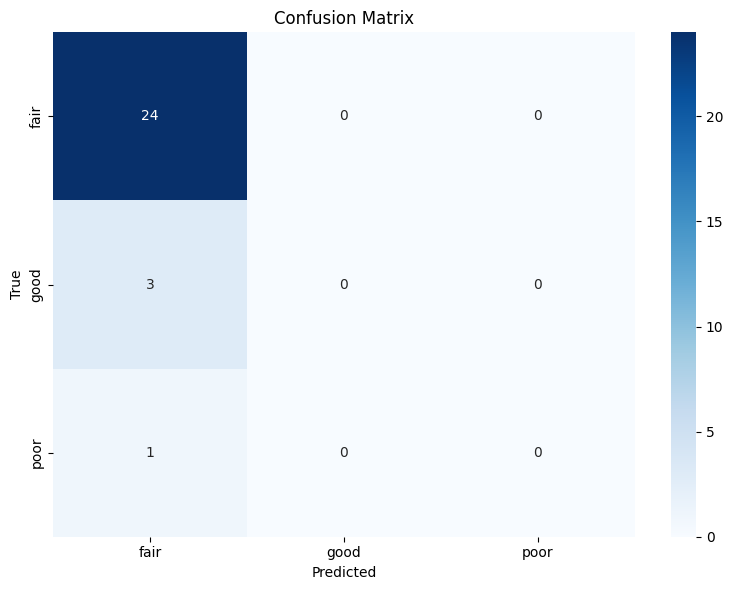

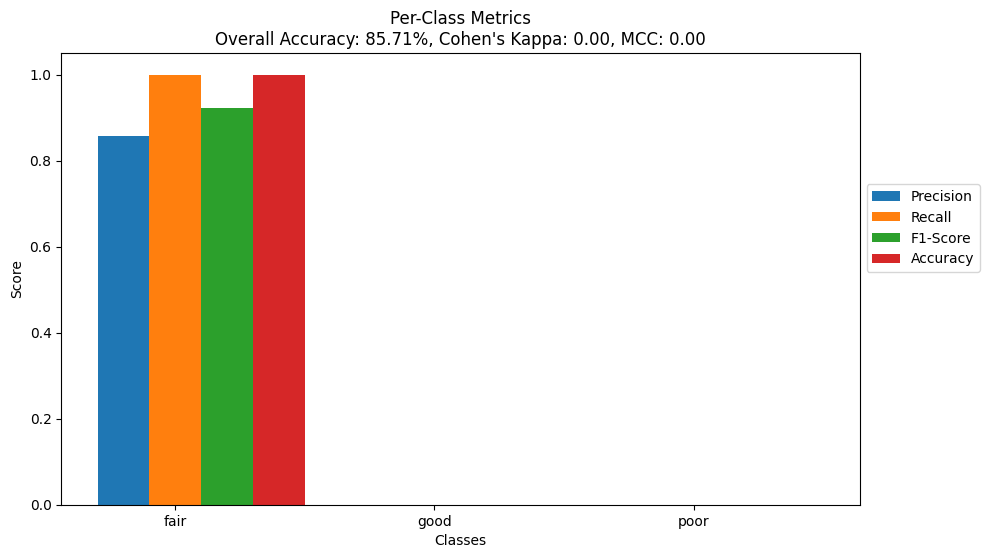

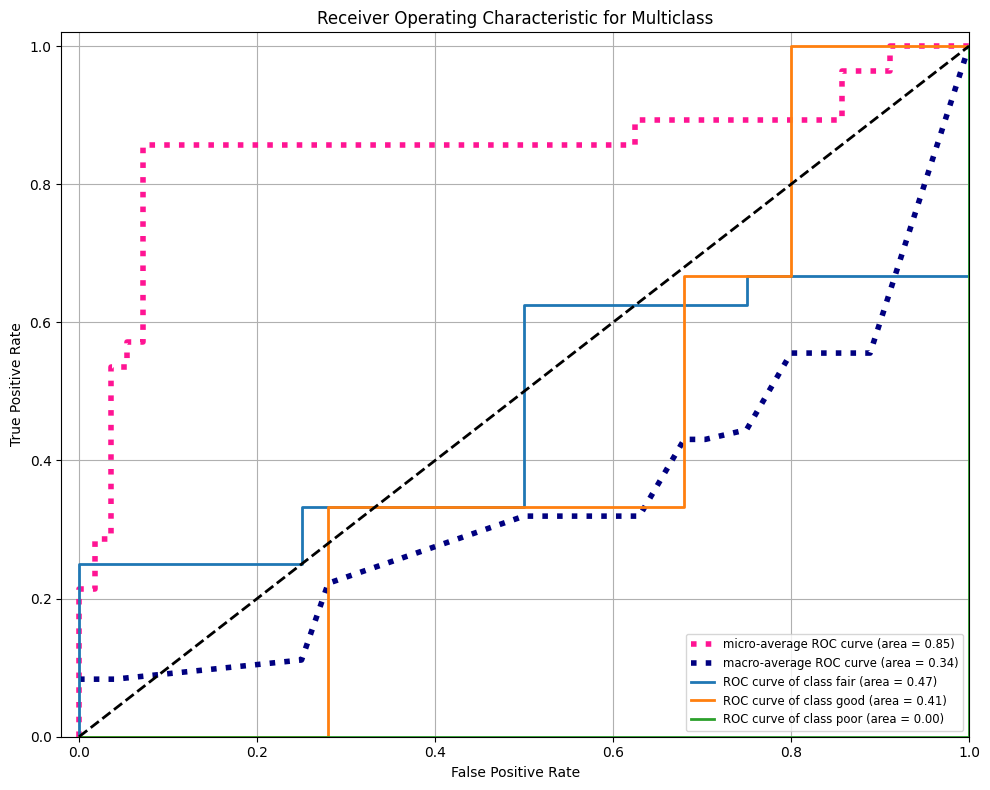

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, cohen_kappa_score, matthews_corrcoef
from sklearn.preprocessing import label_binarize
import numpy as np
import pandas as pd

# Define the plot_metrics function
def plot_metrics(metrics_df, class_names, accuracy, kappa, mcc):
    metrics = ['Precision', 'Recall', 'F1-Score', 'Accuracy']
    plt.figure(figsize=(10, 6))
    x = np.arange(len(class_names))
    width = 0.2
    for i, metric in enumerate(metrics):
        plt.bar(
            x + i * width,
            metrics_df[metric],
            width=width,
            label=metric,
            align='center',
        )
    plt.xlabel('Classes')
    plt.ylabel('Score')
    plt.title(
        'Per-Class Metrics\n'
        f'Overall Accuracy: {accuracy * 100:.2f}%, '
        f"Cohen's Kappa: {kappa:.2f}, MCC: {mcc:.2f}"
    )
    plt.xticks(x + width, class_names)
    plt.ylim(0, 1.05)
    plt.legend(loc='lower left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    # plt.savefig('metrics_plot.pdf')  # Uncomment to save figure
    plt.show()


# Define the plot_roc_curves function
def plot_roc_curves(y_true, probabilities_list, class_names):
    n_classes = len(class_names)
    y_true_binary = label_binarize(y_true, classes=class_names)
    probabilities_array = np.array(probabilities_list)

    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_binary[:, i], probabilities_array[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binary.ravel(), probabilities_array.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Compute macro-average ROC curve and ROC area
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    # Plot all ROC curves
    plt.figure(figsize=(10, 8))
    plt.plot(
        fpr["micro"],
        tpr["micro"],
        label='micro-average ROC curve (area = {0:0.2f})'.format(roc_auc["micro"]),
        color='deeppink',
        linestyle=':',
        linewidth=4,
    )
    plt.plot(
        fpr["macro"],
        tpr["macro"],
        label='macro-average ROC curve (area = {0:0.2f})'.format(roc_auc["macro"]),
        color='navy',
        linestyle=':',
        linewidth=4,
    )
    colors = plt.cm.get_cmap('tab10').colors
    for i, color in zip(range(n_classes), colors):
        plt.plot(
            fpr[i],
            tpr[i],
            color=color,
            lw=2,
            label='ROC curve of class {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]),
        )
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([-0.02, 1.0])
    plt.ylim([0.0, 1.02])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic for Multiclass')
    plt.legend(loc='lower right', fontsize='small')
    plt.grid(True)
    plt.tight_layout()
    # plt.savefig('roc_curves.pdf')  # Uncomment to save figure
    plt.show()

# We must have already loaded X_train_full, Y_train_full, X_test, Y_test
# and defined all helper functions and the RandomForest class.

# Focus on Random_Oversampling as our best result from the previous section
resampling = RandomOverSampler()    #<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<< Insert the best technique here

# Flatten for resampling
def flatten_for_resample(X):
    n_samples, n_channels, series_length = X.shape
    return X.reshape(n_samples, n_channels * series_length)

def reshape_after_resample(X, y, original_shape):
    n_channels = original_shape[1]
    series_length = original_shape[2]
    return X.reshape(-1, n_channels, series_length), y

X_train_flat = flatten_for_resample(X_train)
X_train_res, Y_train_res = resampling.fit_resample(X_train_flat, Y_train)
X_train_resamp, Y_train_resamp = reshape_after_resample(X_train_res, Y_train_res, X_train.shape)

print("Class distribution after Resampling:")
print(pd.Series(Y_train_resamp).value_counts())

# Train RandomForest model on the resampled dataset
rf_resamp = RandomForest(
    n_trees=30,
    maxstep=maxstep,
    stepsize=stepsize,
    maxd=relative_max_depth,
    mins=1, # adjust as needed
    distance_functions=[
        {'metric': 'euclidean', 'params': [{}], 'use_catch22': True},
        {'metric': 'euclidean', 'params': [{}], 'use_catch22': False},
        {'metric': 'dtw', 'params': [{}], 'use_catch22': False},
    ],
    allow_step_reuse=True,
    post_pruning=True,
)

rf_resamp.fit(X_train_resamp, Y_train_resamp)

# Evaluate on test set
y_true_resamp, y_pred_resamp = [], []
probabilities_list = []
for x, y_t in zip(X_test, Y_test):
    prob = rf_resamp.predict_proba(x)  # get the probabilities for plotting ROC
    y_p = max(prob, key=prob.get)
    y_true_resamp.append(y_t)
    y_pred_resamp.append(y_p)
    probabilities = [prob.get(cls, 0) for cls in sorted(np.unique(Y_train_full))]
    probabilities_list.append(probabilities)

class_names = sorted(np.unique(Y_train_full))
report = classification_report(y_true_resamp, y_pred_resamp, labels=class_names, output_dict=True, zero_division='warn')
accuracy = report['accuracy']
macro_f1 = report['macro avg']['f1-score']
kappa = cohen_kappa_score(y_true_resamp, y_pred_resamp)
mcc = matthews_corrcoef(y_true_resamp, y_pred_resamp)

print("=== Resampling Evaluation on Test Set ===")
print("Accuracy:", accuracy)
print("Macro F1-score:", macro_f1)
print("Cohen's Kappa:", kappa)
print("MCC:", mcc)
print("Classification Report:")
print(classification_report(y_true_resamp, y_pred_resamp, labels=class_names, zero_division='warn'))

# Confusion Matrix
cm = confusion_matrix(y_true_resamp, y_pred_resamp, labels=class_names)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Calculate per-class metrics for plotting
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
metrics_df = pd.DataFrame(index=class_names)
metrics_df['Precision'] = [report[str(cls)]['precision'] for cls in class_names]
metrics_df['Recall'] = [report[str(cls)]['recall'] for cls in class_names]
metrics_df['F1-Score'] = [report[str(cls)]['f1-score'] for cls in class_names]
metrics_df['Accuracy'] = per_class_accuracy

# Plot Metrics
plot_metrics(metrics_df, class_names, accuracy, kappa, mcc)

# ROC Curves (for multi-class)
if len(class_names) > 1:
    plot_roc_curves(y_true_resamp, probabilities_list, class_names)
else:
    print("ROC curve is not applicable for a single-class scenario.")